In [156]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import xgboost 
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, 
    roc_curve, precision_recall_curve, make_scorer,RocCurveDisplay
)

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [157]:

df = pd.read_csv('Dataset/data_merged.csv')



In [158]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

df_processed['duration_ms'] = df_processed['duration_ms']/60000



# 1. Variable binaria (popular vs no popular)
# la mediana como punto de corte
popularity_median = df_processed['popularity'].median()
print(f"   - Mediana de popularidad: {popularity_median}")
df_processed['is_popular_binary'] = (df_processed['popularity'] > popularity_median).astype(int)

# 2. Variable multiclase (3 niveles: Baja, Media, Alta)
# Usar terciles para dividir en 3 categorías
terciles = df_processed['popularity'].quantile([0.33, 0.67])
print(f"   - Terciles de popularidad: {terciles.values}")

def categorize_popularity(popularity):
    if popularity <= terciles[0.33]:
        return 0  # Baja
    elif popularity <= terciles[0.67]:
        return 1  # Media
    else:
        return 2  # Alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)

# 3. Variable multiclase (5 niveles: Muy Baja, Baja, Media, Alta, Muy Alta)
quintiles = df_processed['popularity'].quantile([0.2, 0.4, 0.6, 0.8])
print(f"   - Quintiles de popularidad: {quintiles.values}")

def categorize_popularity_5levels(popularity):
    if popularity <= quintiles[0.2]:
        return 0  # Muy Baja
    elif popularity <= quintiles[0.4]:
        return 1  # Baja
    elif popularity <= quintiles[0.6]:
        return 2  # Media
    elif popularity <= quintiles[0.8]:
        return 3  # Alta
    else:
        return 4  # Muy Alta

df_processed['popularity_5levels'] = df_processed['popularity'].apply(categorize_popularity_5levels)

print("Variable binaria (is_popular_binary):")
print(df_processed['is_popular_binary'].value_counts().sort_index())
print(f"   Proporción: {df_processed['is_popular_binary'].mean():.3f}")

print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")

print("\nVariable multiclase 5 niveles (popularity_5levels):")
fiveclass_counts = df_processed['popularity_5levels'].value_counts().sort_index()
fiveclass_labels = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
for i, (count, label) in enumerate(zip(fiveclass_counts, fiveclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")

print(f"\n✅ Preprocesamiento completado")
print(f"📊 Dataset final: {df_processed.shape[0]} filas, {df_processed.shape[1]} columnas")

   - Mediana de popularidad: 26.0
   - Terciles de popularidad: [ 9. 37.]
   - Quintiles de popularidad: [ 0. 17. 32. 46.]
Variable binaria (is_popular_binary):
is_popular_binary
0    88034
1    84196
Name: count, dtype: int64
   Proporción: 0.489

Variable multiclase 3 niveles (popularity_multiclass):
   0 (Baja): 57080 (33.1%)
   1 (Media): 60091 (34.9%)
   2 (Alta): 55059 (32.0%)

Variable multiclase 5 niveles (popularity_5levels):
   0 (Muy Baja): 39729 (23.1%)
   1 (Baja): 29179 (16.9%)
   2 (Media): 34591 (20.1%)
   3 (Alta): 34303 (19.9%)
   4 (Muy Alta): 34428 (20.0%)

✅ Preprocesamiento completado
📊 Dataset final: 172230 filas, 75 columnas


<Axes: xlabel='popularity_5levels'>

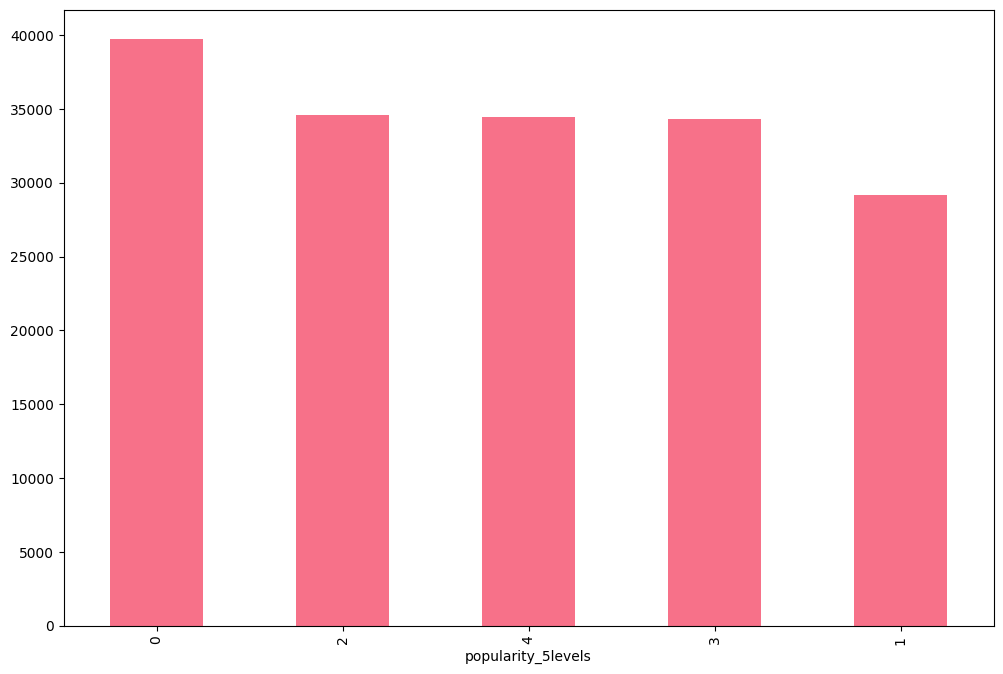

In [159]:
df_processed['popularity_5levels'].value_counts().plot(kind='bar')

<Axes: xlabel='popularity_multiclass'>

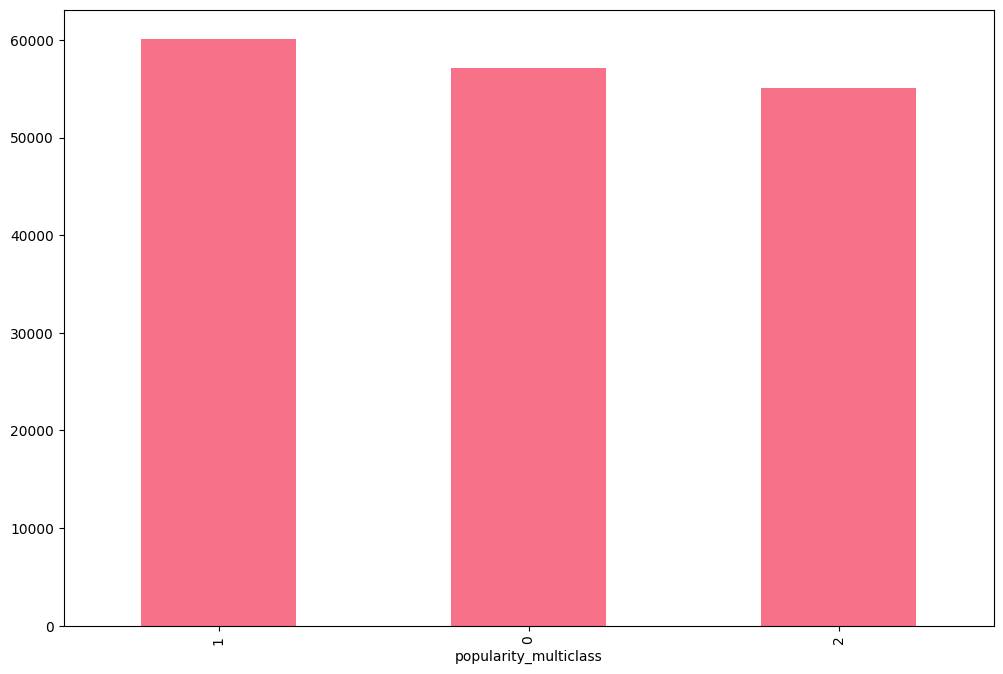

In [160]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

<Axes: xlabel='is_popular_binary'>

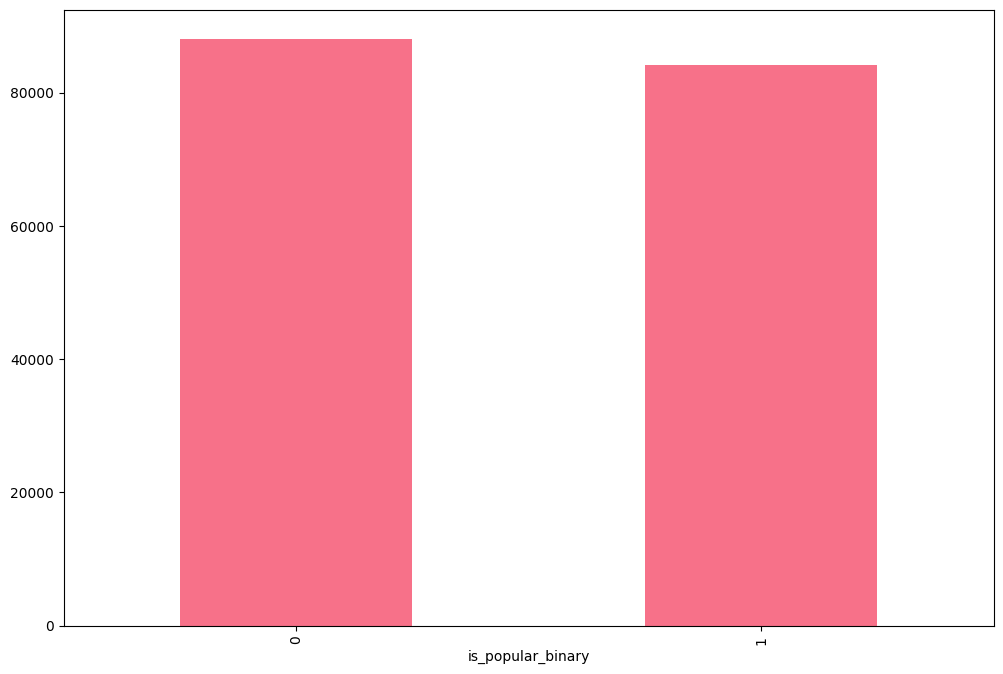

In [161]:
df_processed['is_popular_binary'].value_counts().plot(kind='bar')

In [162]:
scaler = RobustScaler()
scaler1 = RobustScaler()
scaler2 = RobustScaler()
_X = df_processed.copy()
X = _X.drop(columns=['popularity','popularity_multiclass','is_popular_binary','popularity_5levels'])
y_binary = df_processed['is_popular_binary']
y_multiclass_3 = df_processed['popularity_multiclass'] 
y_multiclass_5 = df_processed['popularity_5levels']


test_size = 0.2
random_state = 42

# División para clasificación binaria
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, 
    test_size=test_size, 
    stratify=y_binary,
    random_state=random_state
)
X_train_bin = scaler.fit_transform(X_train_bin)
# División para clasificación multiclase (3 niveles)
X_train_multi3, X_test_multi3, y_train_multi3, y_test_multi3 = train_test_split(
    X, y_multiclass_3, 
    test_size=test_size, 
    stratify=y_multiclass_3,
    random_state=random_state
)
X_train_multi3 = scaler1.fit_transform(X_train_multi3)
# División para clasificación multiclase (5 niveles)
X_train_multi5, X_test_multi5, y_train_multi5, y_test_multi5 = train_test_split(
    X, y_multiclass_5, 
    test_size=test_size, 
    stratify=y_multiclass_5,
    random_state=random_state
)
X_train_multi5= scaler2.fit_transform(X_train_multi5)


In [163]:
import time
base_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10
    ),
    
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    ),
    
    'Naive Bayes': GaussianNB(),
    
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        n_jobs=-1
    ),
}



In [ ]:
# CLASIFICACIÓN BINARIA 

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, task_type,_scaler):
    """
    Evalúa un modelo y retorna métricas de rendimiento
    """
    print(f"Entrenando {model_name}...",flush=True)

    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
   
    start_time = time.time()
    X_test = _scaler.transform(X_test)
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start_time
    
 
    accuracy = accuracy_score(y_test, y_pred)
    
    if task_type == 'binary':
        precision = precision_score(y_test, y_pred, pos_label=1)
        recall = recall_score(y_test, y_pred, pos_label=1)
        f1 = f1_score(y_test, y_pred, pos_label=1)
        
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)
        else:
            roc_auc = None
    else:
     
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        roc_auc = None  
        
    print(f"   Completado - Accuracy: {accuracy:.4f}, F1: {f1:.4f}",flush=True)

    results = {
        'model_name': model_name,
        'task_type': task_type,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'model_object': model,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    return results




binary_results = [] 
for model_name, model in base_models.items():
    try:
        result = evaluate_model(
            model=model,
            X_train=X_train_bin,
            X_test=X_test_bin,
            y_train=y_train_bin,
            y_test=y_test_bin,
            model_name=model_name,
            task_type='binary',
            _scaler=scaler
        )
        binary_results.append(result)
    except Exception as e:
        print(f"   ❌ Error con {model_name}: {str(e)}")


binary_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'ROC AUC': r['roc_auc'] if r['roc_auc'] else 'N/A',
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in binary_results])

binary_df = binary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)


print(binary_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].barh(binary_df['Modelo'], binary_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Clasificación Binaria', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].barh(binary_df['Modelo'], binary_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Clasificación Binaria', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(binary_df['Recall'], binary_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(binary_df['Modelo']):
    axes[1,0].annotate(txt, (binary_df['Recall'].iloc[i], binary_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Clasificación Binaria', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(binary_df['Modelo'], binary_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Clasificación Binaria', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


best_binary_model = binary_results[0]['model_object']
best_binary_name = binary_results[0]['model_name']

for i,_ in enumerate(binary_results):
    plt.figure(figsize=(8, 6))
    cm = binary_results[i]['confusion_matrix']
    name = binary_results[i]['model_name']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'Popular'],
                yticklabels=['No Popular', 'Popular'])
    plt.title(f'Matriz de Confusión - {name}\nClasificación Binaria', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

print(f"\nClasificación binaria completada con {len(binary_results)} modelos")

Entrenando Logistic Regression...
   Completado - Accuracy: 0.8926, F1: 0.8927
Entrenando Random Forest...


Entrenando Random Forest...
   Completado - Accuracy: 0.8494, F1: 0.8493
Entrenando Gradient Boosting...
   Completado - Accuracy: 0.8345, F1: 0.8348
Entrenando Decision Tree...
   Completado - Accuracy: 0.8358, F1: 0.8364
Entrenando K-Nearest Neighbors...
   Completado - Accuracy: 0.7678, F1: 0.7679
Entrenando Extra Trees...
   Completado - Accuracy: 0.8361, F1: 0.8360
                Modelo  Accuracy  Precision  Recall  F1-Score  \
0        Random Forest    0.8494     0.8511  0.8494    0.8493   
1        Decision Tree    0.8358     0.8411  0.8358    0.8364   
2          Extra Trees    0.8361     0.8369  0.8361    0.8360   
3    Gradient Boosting    0.8345     0.8372  0.8345    0.8348   
4  K-Nearest Neighbors    0.7678     0.7682  0.7678    0.7679   

   Tiempo Entrenamiento (s)  Tiempo Predicción (s)  
0                   15.0685                 0.3024  
1                    4.1431                 0.0301  
2                   11.8266                 0.4495  
3                  441.4

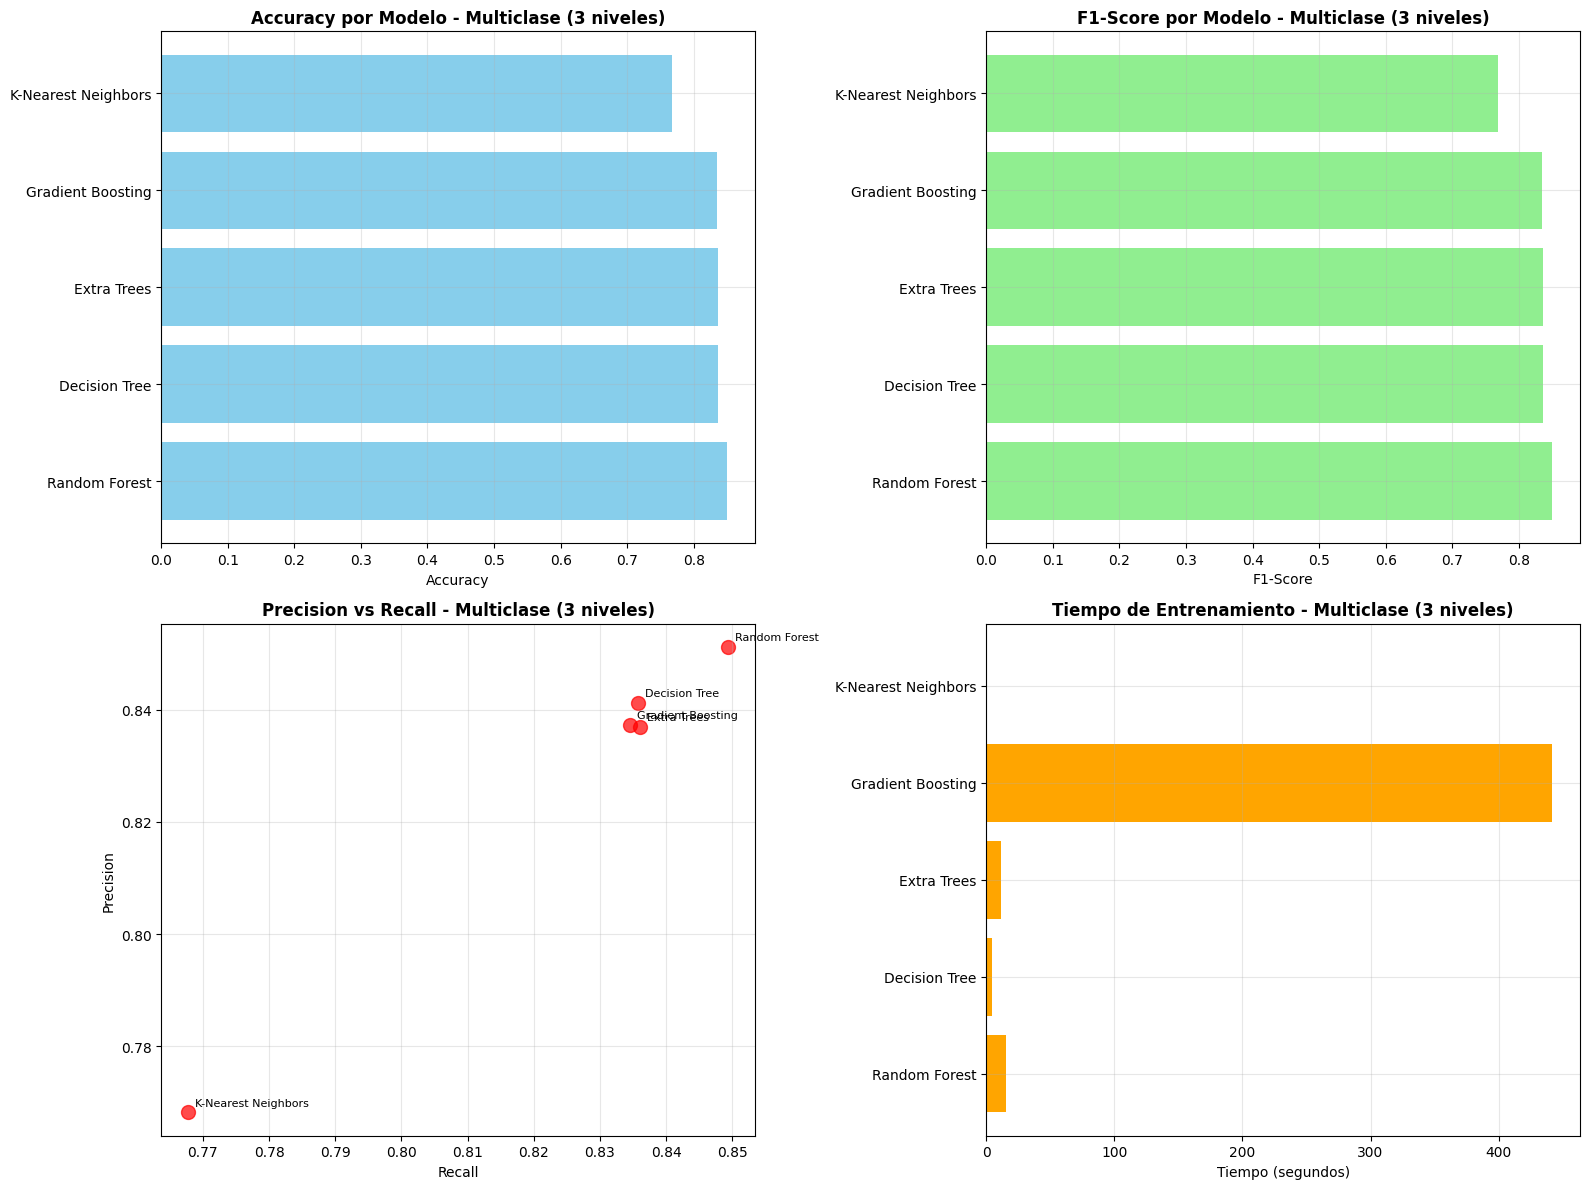

              precision    recall  f1-score   support

        Baja     0.9432    0.9525    0.9478     11416
       Media     0.7668    0.8233    0.7940     12018
        Alta     0.8477    0.7709    0.8075     11012

    accuracy                         0.8494     34446
   macro avg     0.8526    0.8489    0.8498     34446
weighted avg     0.8511    0.8494    0.8493     34446



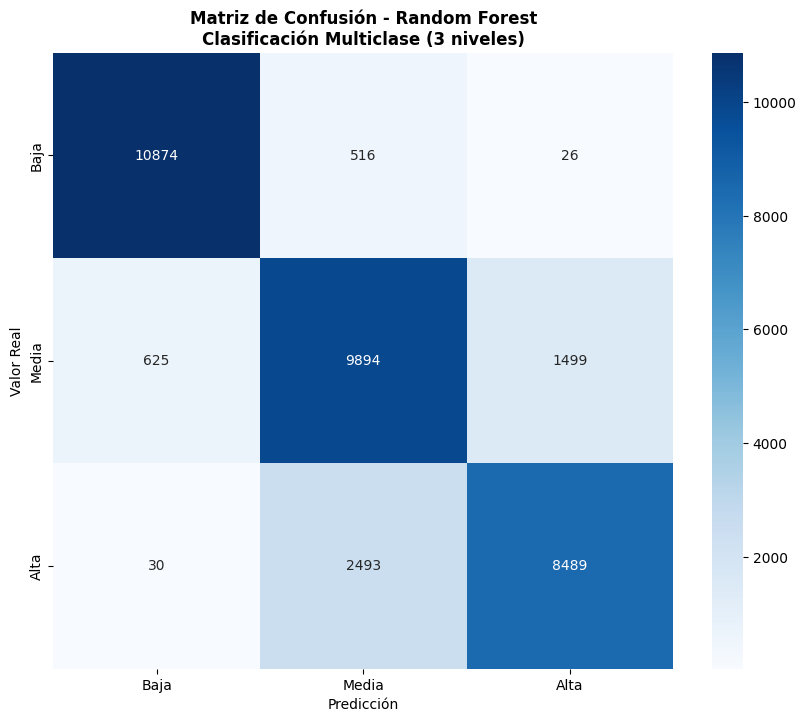

              precision    recall  f1-score   support

        Baja     0.9347    0.9332    0.9339     11416
       Media     0.7455    0.8089    0.7759     12018
        Alta     0.8363    0.7602    0.7964     11012

    accuracy                         0.8345     34446
   macro avg     0.8388    0.8341    0.8354     34446
weighted avg     0.8372    0.8345    0.8348     34446



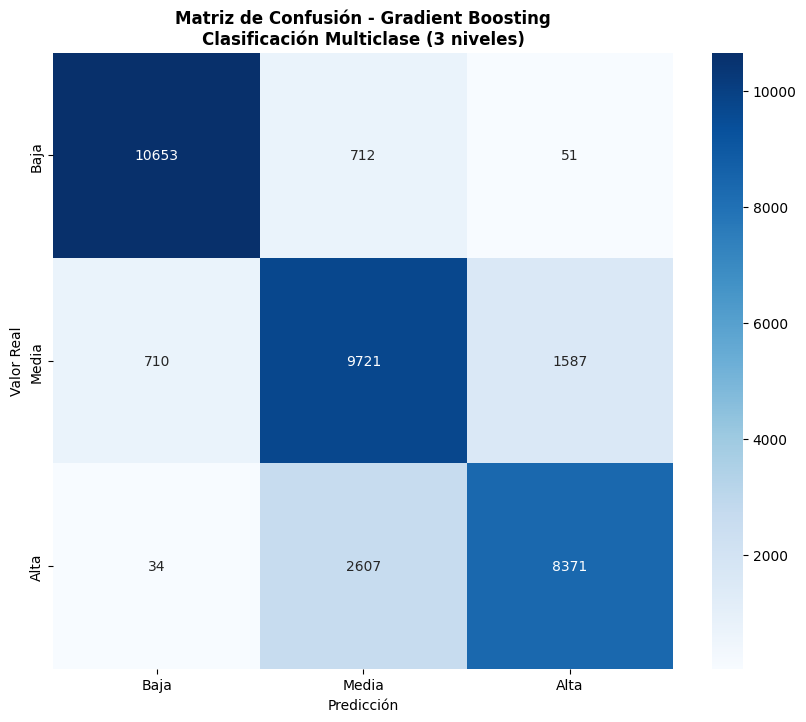

              precision    recall  f1-score   support

        Baja     0.9440    0.9299    0.9369     11416
       Media     0.7378    0.8312    0.7817     12018
        Alta     0.8471    0.7433    0.7918     11012

    accuracy                         0.8358     34446
   macro avg     0.8430    0.8348    0.8368     34446
weighted avg     0.8411    0.8358    0.8364     34446



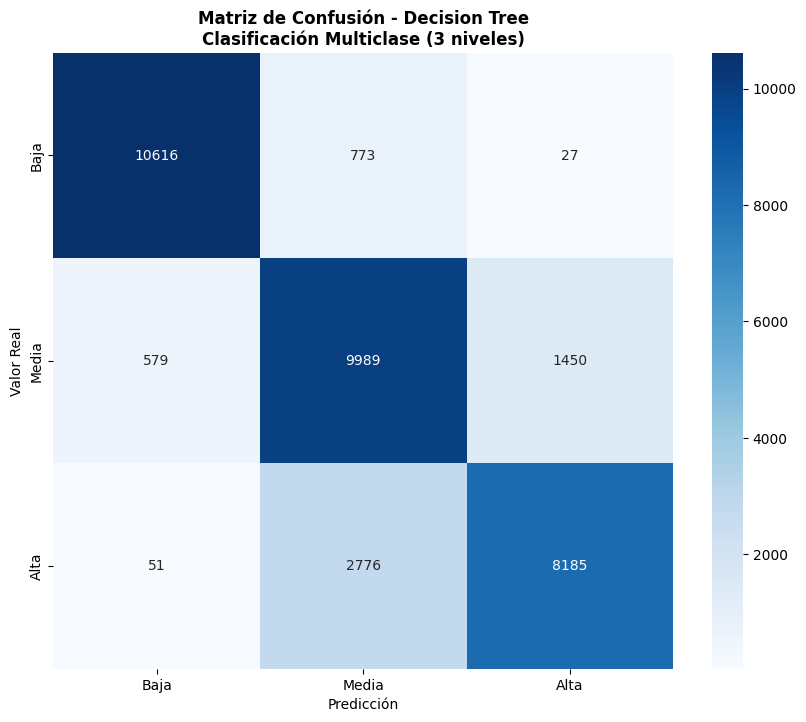

              precision    recall  f1-score   support

        Baja     0.8885    0.8840    0.8863     11416
       Media     0.7001    0.7172    0.7085     12018
        Alta     0.7178    0.7025    0.7101     11012

    accuracy                         0.7678     34446
   macro avg     0.7688    0.7679    0.7683     34446
weighted avg     0.7682    0.7678    0.7679     34446



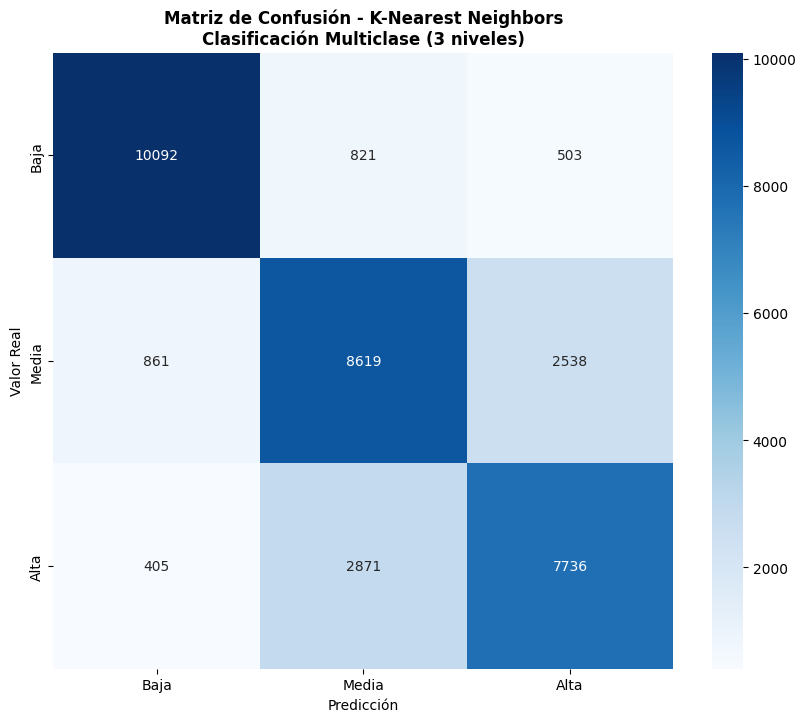

              precision    recall  f1-score   support

        Baja     0.9386    0.9505    0.9445     11416
       Media     0.7541    0.7947    0.7739     12018
        Alta     0.8218    0.7627    0.7912     11012

    accuracy                         0.8361     34446
   macro avg     0.8382    0.8360    0.8365     34446
weighted avg     0.8369    0.8361    0.8360     34446



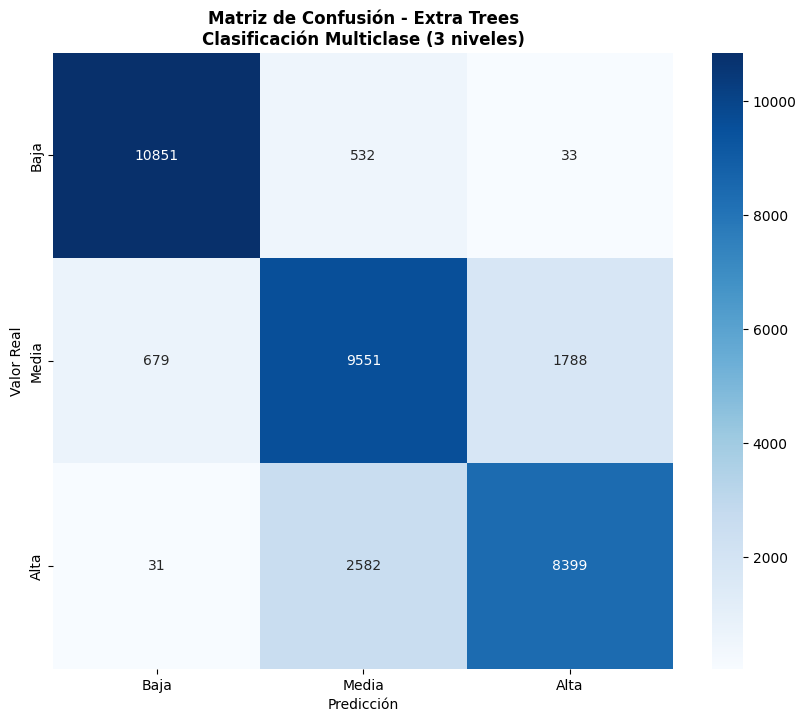


Clasificación multiclase (3 niveles) completada con 5 modelos


In [ ]:
# CLASIFICACIÓN MULTICLASE (3 NIVELES) 


multiclass3_results = []

for model_name, model in base_models.items():
    if model_name == 'Logistic Regression' or model_name=='Naive Bayes':
        continue
    try:
        result = evaluate_model(
            model=model,
            X_train=X_train_multi3,
            X_test=X_test_multi3,
            y_train=y_train_multi3,
            y_test=y_test_multi3,
            model_name=model_name,
            task_type='multiclass',
            _scaler=scaler1
        )
        multiclass3_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con {model_name}: {str(e)}")

multiclass3_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in multiclass3_results])

multiclass3_df = multiclass3_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)


print(multiclass3_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].barh(multiclass3_df['Modelo'], multiclass3_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (3 niveles)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].barh(multiclass3_df['Modelo'], multiclass3_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (3 niveles)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(multiclass3_df['Recall'], multiclass3_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(multiclass3_df['Modelo']):
    axes[1,0].annotate(txt, (multiclass3_df['Recall'].iloc[i], multiclass3_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (3 niveles)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(multiclass3_df['Modelo'], multiclass3_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (3 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


best_multi3_model = multiclass3_results[0]['model_object']
best_multi3_name = multiclass3_results[0]['model_name']


for i,_ in enumerate(multiclass3_results):
    plt.figure(figsize=(10, 8))
    cm = multiclass3_results[i]['confusion_matrix']
    _name = multiclass3_results[i]['model_name']
    class_names = ['Baja', 'Media', 'Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Matriz de Confusión - {_name}\nClasificación Multiclase (3 niveles)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi3, multiclass3_results[i]['predictions'], 
                             target_names=class_names, digits=4)
    print(report)
    plt.show()



print(f"\nClasificación multiclase (3 niveles) completada con {len(multiclass3_results)} modelos")

Entrenando Random Forest...
   Completado - Accuracy: 0.7468, F1: 0.7464
Entrenando Gradient Boosting...
   Completado - Accuracy: 0.7290, F1: 0.7300
Entrenando Decision Tree...
   Completado - Accuracy: 0.7266, F1: 0.7276
Entrenando K-Nearest Neighbors...
   Completado - Accuracy: 0.6505, F1: 0.6502
Entrenando Extra Trees...
   Completado - Accuracy: 0.7306, F1: 0.7300
                Modelo  Accuracy  Precision  Recall  F1-Score  \
0        Random Forest    0.7468     0.7490  0.7468    0.7464   
1          Extra Trees    0.7306     0.7316  0.7306    0.7300   
2    Gradient Boosting    0.7290     0.7366  0.7290    0.7300   
3        Decision Tree    0.7266     0.7351  0.7266    0.7276   
4  K-Nearest Neighbors    0.6505     0.6503  0.6505    0.6502   

   Tiempo Entrenamiento (s)  Tiempo Predicción (s)  
0                   20.3497                 0.3691  
1                   17.9252                 0.5559  
2                  712.1768                 0.5423  
3                    4.4

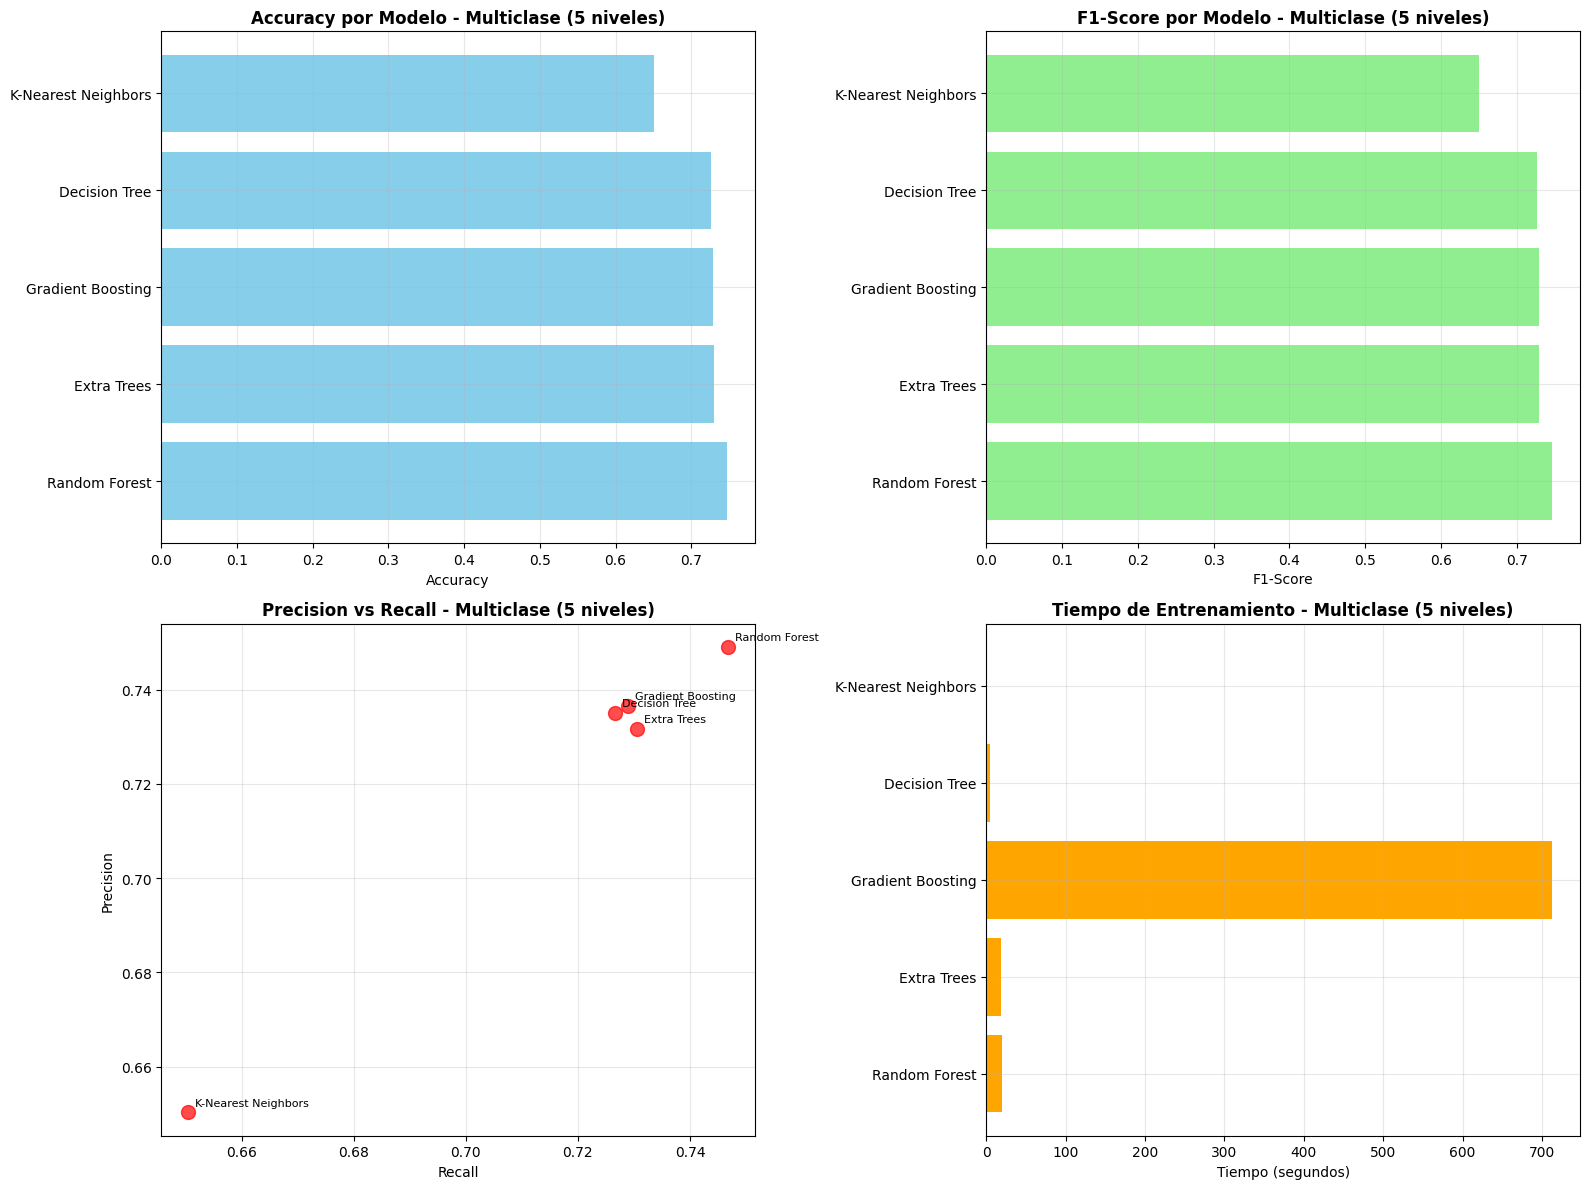

              precision    recall  f1-score   support

    Muy Baja     0.9305    0.9561    0.9431      7946
        Baja     0.7644    0.8060    0.7847      5836
       Media     0.6127    0.6821    0.6456      6918
        Alta     0.5972    0.5689    0.5827      6861
    Muy Alta     0.8148    0.6972    0.7514      6885

    accuracy                         0.7468     34446
   macro avg     0.7439    0.7421    0.7415     34446
weighted avg     0.7490    0.7468    0.7464     34446



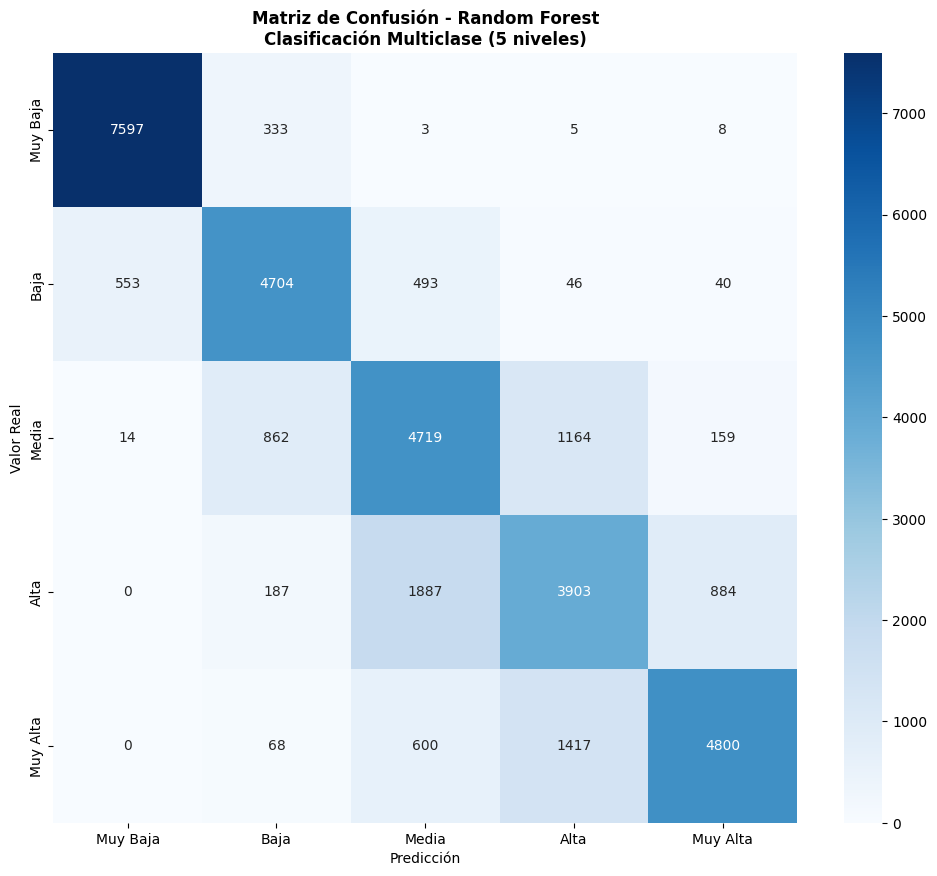

              precision    recall  f1-score   support

    Muy Baja     0.9230    0.9275    0.9252      7946
        Baja     0.7017    0.7853    0.7412      5836
       Media     0.5859    0.6644    0.6226      6918
        Alta     0.5954    0.5709    0.5829      6861
    Muy Alta     0.8434    0.6745    0.7496      6885

    accuracy                         0.7290     34446
   macro avg     0.7299    0.7245    0.7243     34446
weighted avg     0.7366    0.7290    0.7300     34446



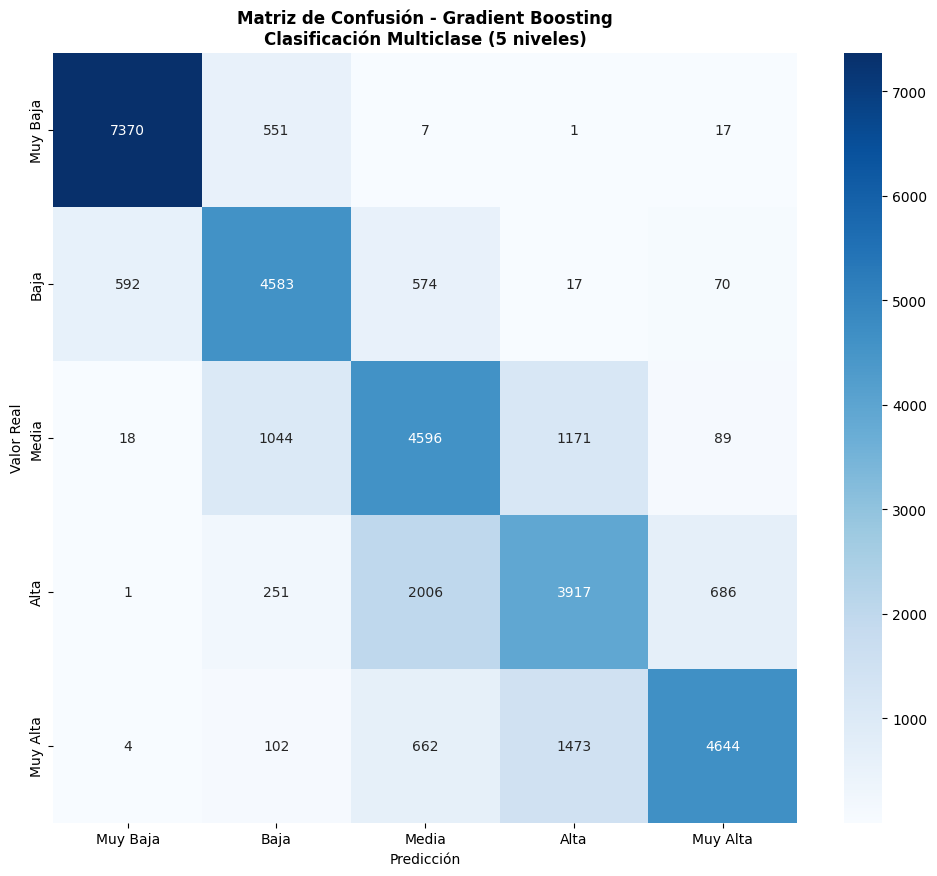

              precision    recall  f1-score   support

    Muy Baja     0.9195    0.9284    0.9239      7946
        Baja     0.6862    0.8033    0.7401      5836
       Media     0.6010    0.6081    0.6045      6918
        Alta     0.5768    0.6084    0.5922      6861
    Muy Alta     0.8560    0.6658    0.7490      6885

    accuracy                         0.7266     34446
   macro avg     0.7279    0.7228    0.7220     34446
weighted avg     0.7351    0.7266    0.7276     34446



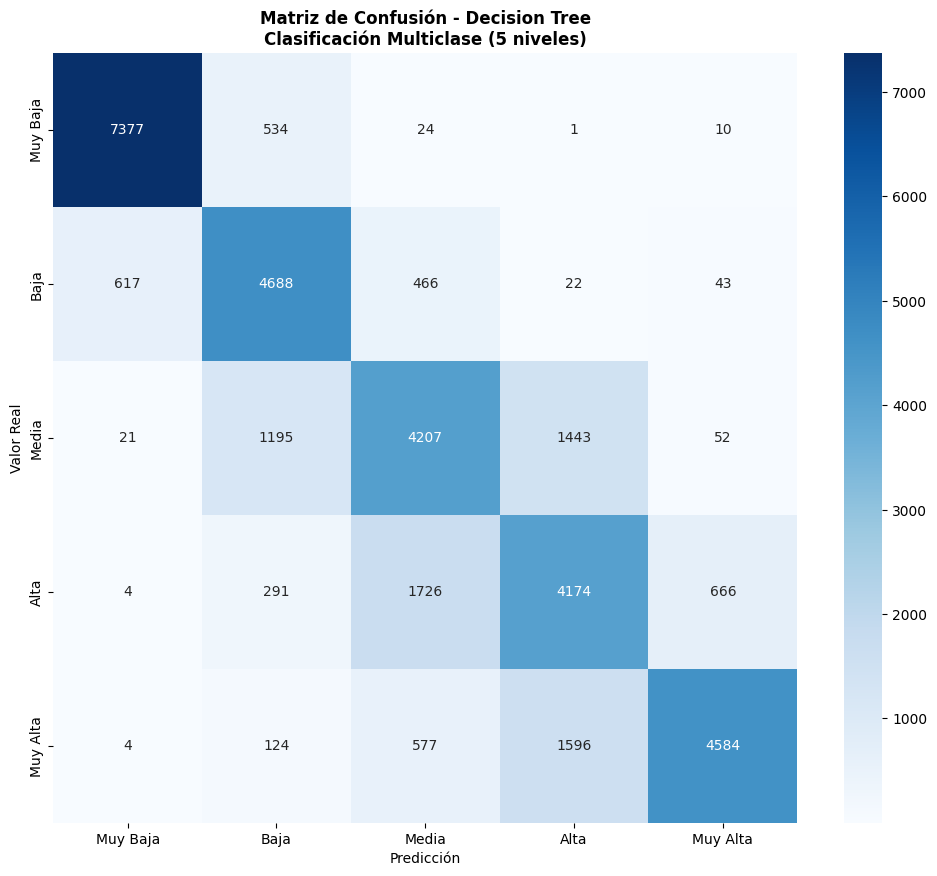

              precision    recall  f1-score   support

    Muy Baja     0.8593    0.8629    0.8611      7946
        Baja     0.6824    0.6880    0.6852      5836
       Media     0.5448    0.5737    0.5589      6918
        Alta     0.5064    0.4899    0.4980      6861
    Muy Alta     0.6312    0.6106    0.6207      6885

    accuracy                         0.6505     34446
   macro avg     0.6448    0.6450    0.6448     34446
weighted avg     0.6503    0.6505    0.6502     34446



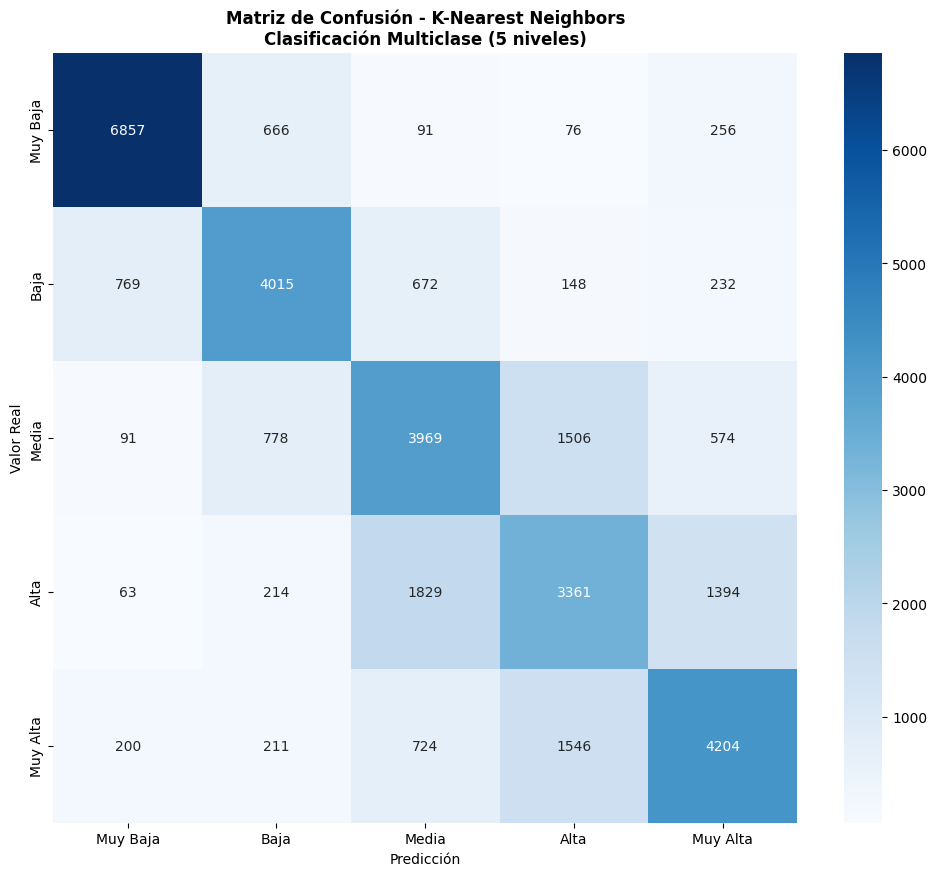

              precision    recall  f1-score   support

    Muy Baja     0.9140    0.9553    0.9342      7946
        Baja     0.7623    0.7719    0.7671      5836
       Media     0.5972    0.6525    0.6236      6918
        Alta     0.5717    0.5541    0.5628      6861
    Muy Alta     0.7893    0.6903    0.7365      6885

    accuracy                         0.7306     34446
   macro avg     0.7269    0.7248    0.7248     34446
weighted avg     0.7316    0.7306    0.7300     34446



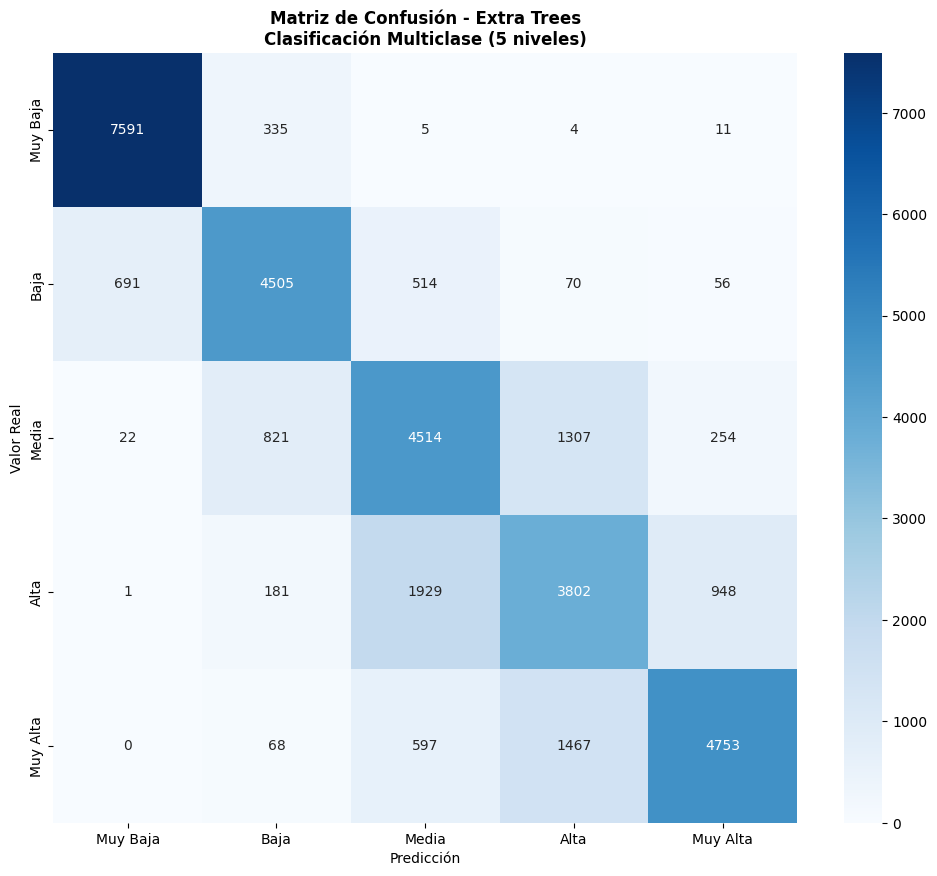


Clasificación multiclase (5 niveles) completada con 5 modelos


In [ ]:

multiclass5_results = []

for model_name, model in base_models.items():
    try:
        if model_name == 'Logistic Regression' or model_name=='Naive Bayes':
            continue
        result = evaluate_model(
            model=model,
            X_train=X_train_multi5,
            X_test=X_test_multi5,
            y_train=y_train_multi5,
            y_test=y_test_multi5,
            model_name=model_name,
            task_type='multiclass',
            _scaler = scaler2
        )
        multiclass5_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con {model_name}: {str(e)}")

multiclass5_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in multiclass5_results])

multiclass5_df = multiclass5_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(multiclass5_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(multiclass5_df['Modelo'], multiclass5_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (5 niveles)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(multiclass5_df['Modelo'], multiclass5_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (5 niveles)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(multiclass5_df['Recall'], multiclass5_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(multiclass5_df['Modelo']):
    axes[1,0].annotate(txt, (multiclass5_df['Recall'].iloc[i], multiclass5_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (5 niveles)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(multiclass5_df['Modelo'], multiclass5_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (5 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_multi5_model = multiclass5_results[0]['model_object']
best_multi5_name = multiclass5_results[0]['model_name']

for i,_ in enumerate(multiclass5_results):
    plt.figure(figsize=(12, 10))
    cm = multiclass5_results[i]['confusion_matrix']
    name_ = multiclass5_results[i]['model_name']
    class_names_5 = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (5 niveles)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi5, multiclass5_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()




print(f"\nClasificación multiclase (5 niveles) completada con {len(multiclass5_results)} modelos")

Entrenando OvR Logistic Regression...
   Completado - Accuracy: 0.7959, F1: 0.7922, Clasificadores: 3
Entrenando OvR Decision Tree...
   Completado - Accuracy: 0.8386, F1: 0.8388, Clasificadores: 3
Entrenando OvR Random Forest...
   Completado - Accuracy: 0.8483, F1: 0.8483, Clasificadores: 3
Entrenando OvR Gradient Boosting...
   Completado - Accuracy: 0.8303, F1: 0.8303, Clasificadores: 3
Entrenando OvR xgboost...
   Completado - Accuracy: 0.8477, F1: 0.8481, Clasificadores: 3
Entrenando OvR Naive Bayes...
   Completado - Accuracy: 0.6875, F1: 0.6783, Clasificadores: 3

RESULTADOS OvR - MULTICLASE (3 NIVELES):
                    Modelo  Accuracy  Precision  Recall  F1-Score  \
0        OvR Random Forest    0.8483     0.8498  0.8483    0.8483   
1              OvR xgboost    0.8477     0.8510  0.8477    0.8481   
2        OvR Decision Tree    0.8386     0.8440  0.8386    0.8388   
3    OvR Gradient Boosting    0.8303     0.8326  0.8303    0.8303   
4  OvR Logistic Regression    0.795

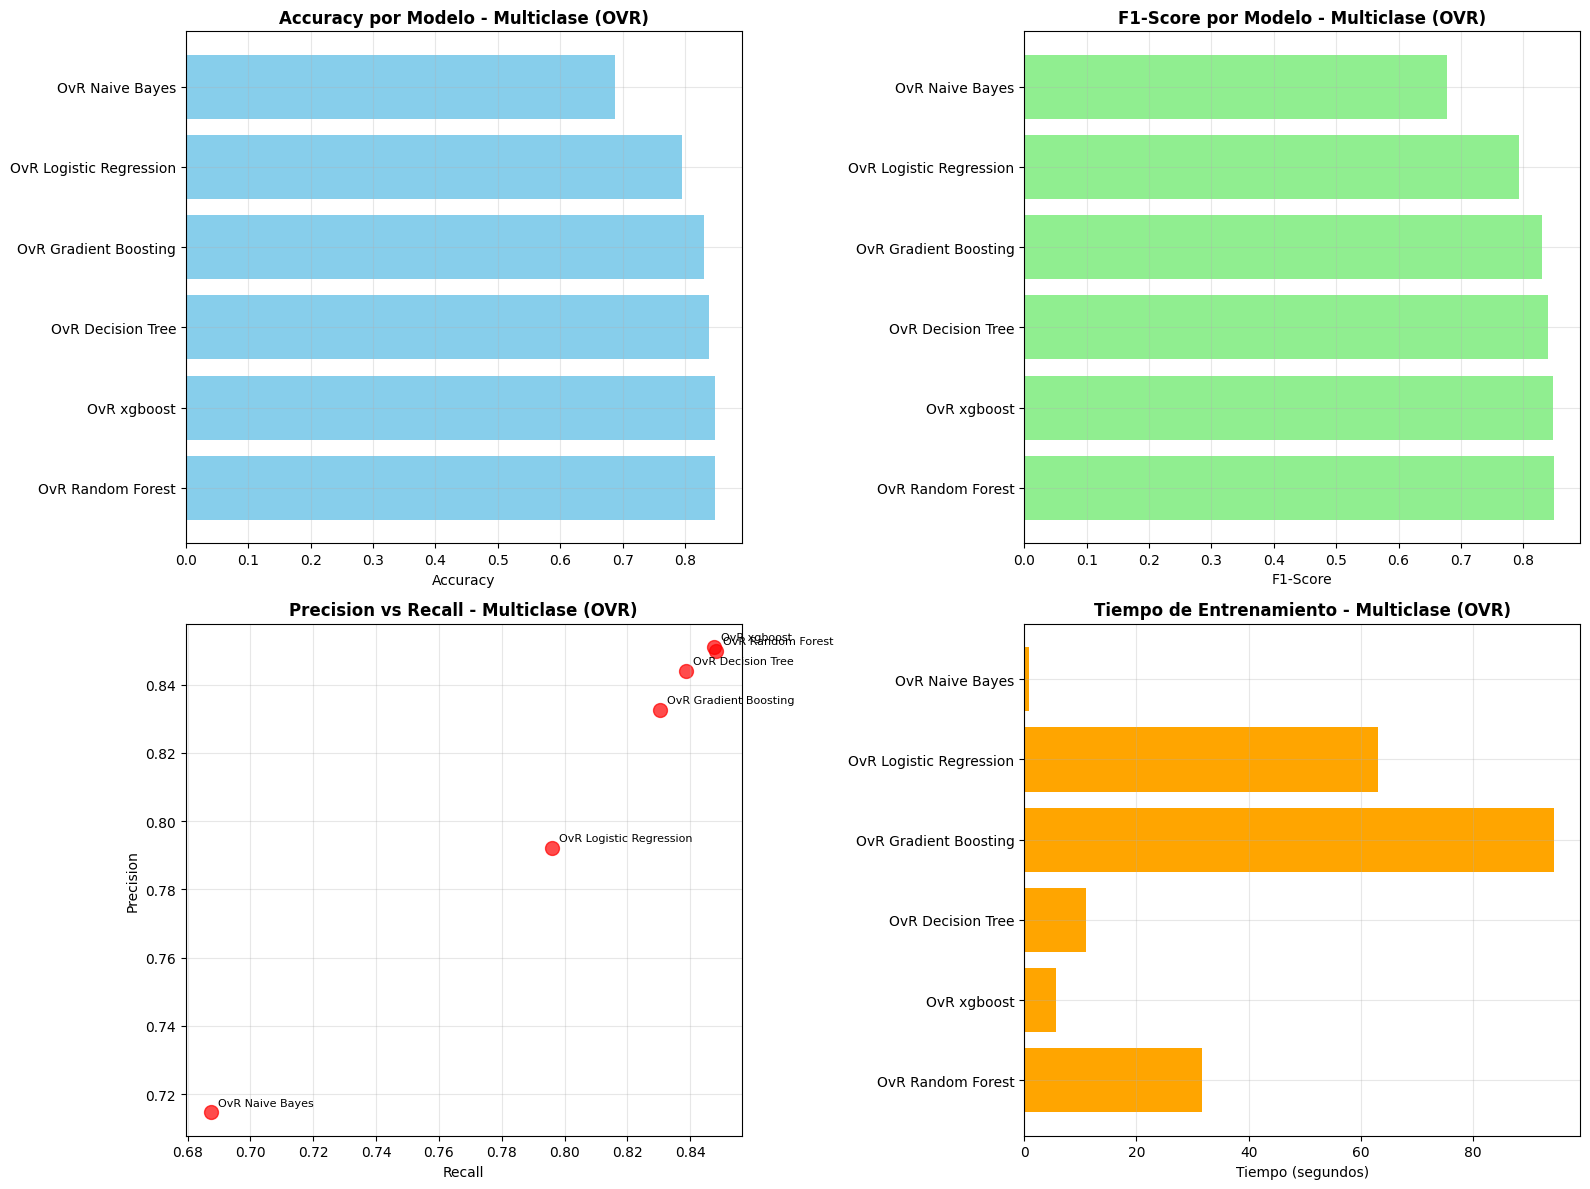

              precision    recall  f1-score   support

        Baja     0.8640    0.9430    0.9017     11416
       Media     0.7463    0.6524    0.6962     12018
        Alta     0.7675    0.8001    0.7835     11012

    accuracy                         0.7959     34446
   macro avg     0.7926    0.7985    0.7938     34446
weighted avg     0.7921    0.7959    0.7922     34446



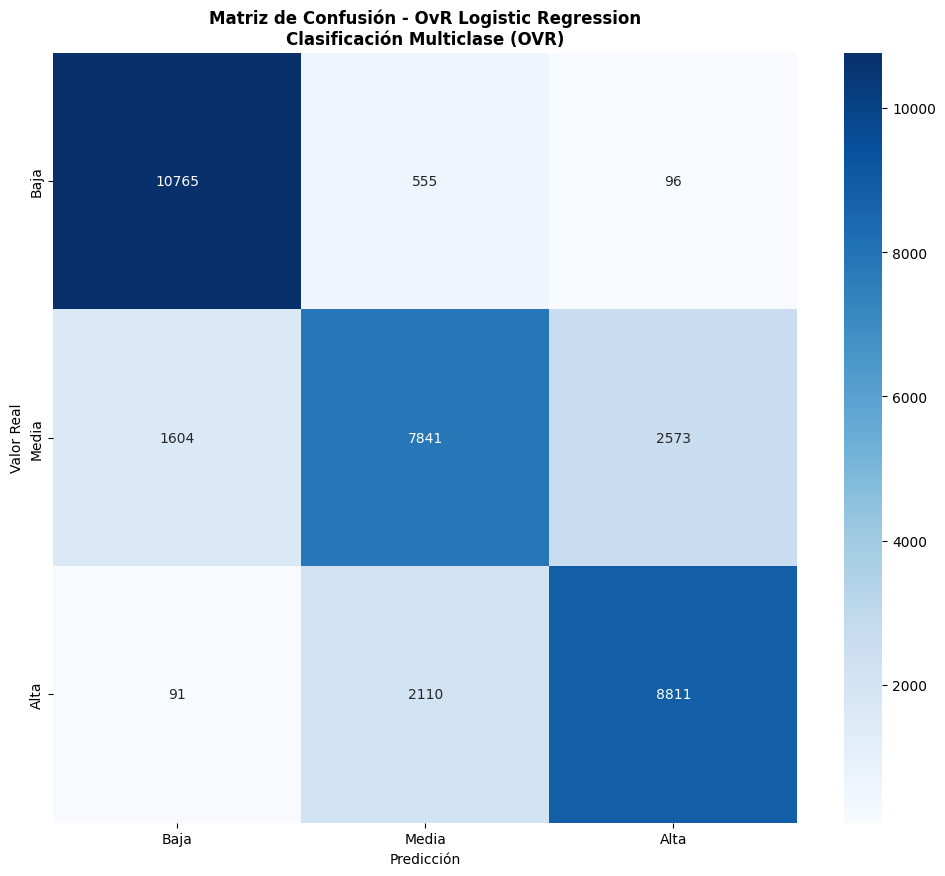

              precision    recall  f1-score   support

        Baja     0.9388    0.9382    0.9385     11416
       Media     0.7407    0.8369    0.7859     12018
        Alta     0.8583    0.7373    0.7932     11012

    accuracy                         0.8386     34446
   macro avg     0.8460    0.8375    0.8392     34446
weighted avg     0.8440    0.8386    0.8388     34446



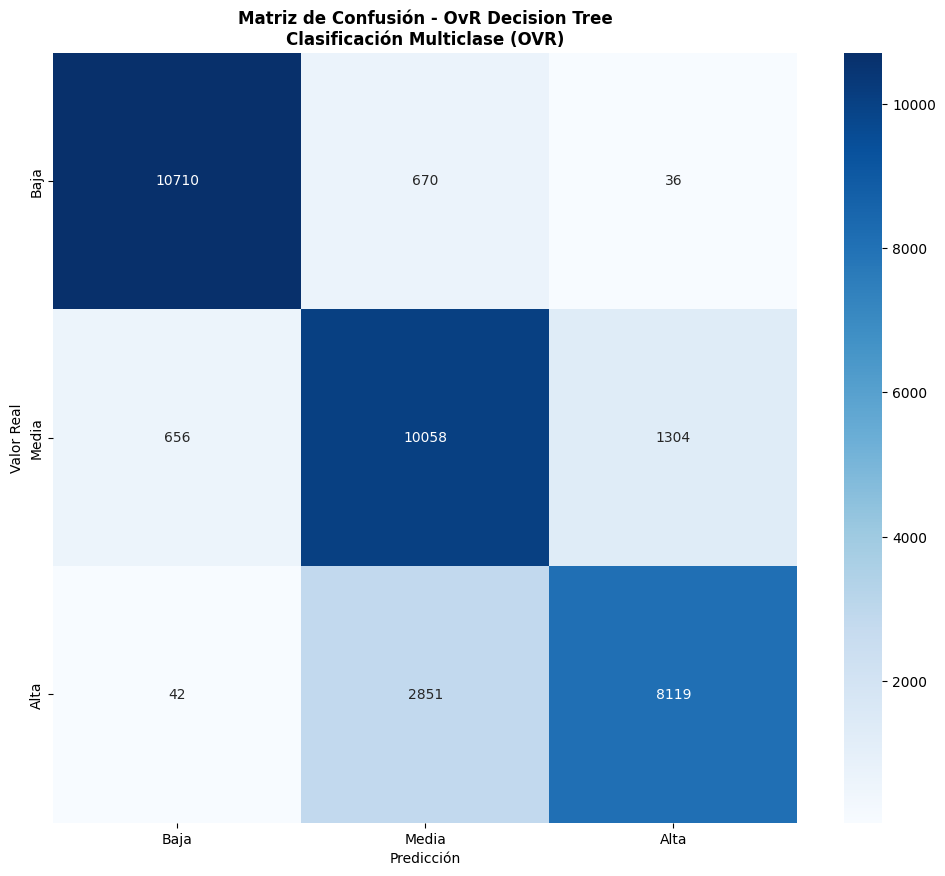

              precision    recall  f1-score   support

        Baja     0.9449    0.9501    0.9475     11416
       Media     0.7671    0.8187    0.7920     12018
        Alta     0.8416    0.7751    0.8070     11012

    accuracy                         0.8483     34446
   macro avg     0.8512    0.8479    0.8488     34446
weighted avg     0.8498    0.8483    0.8483     34446



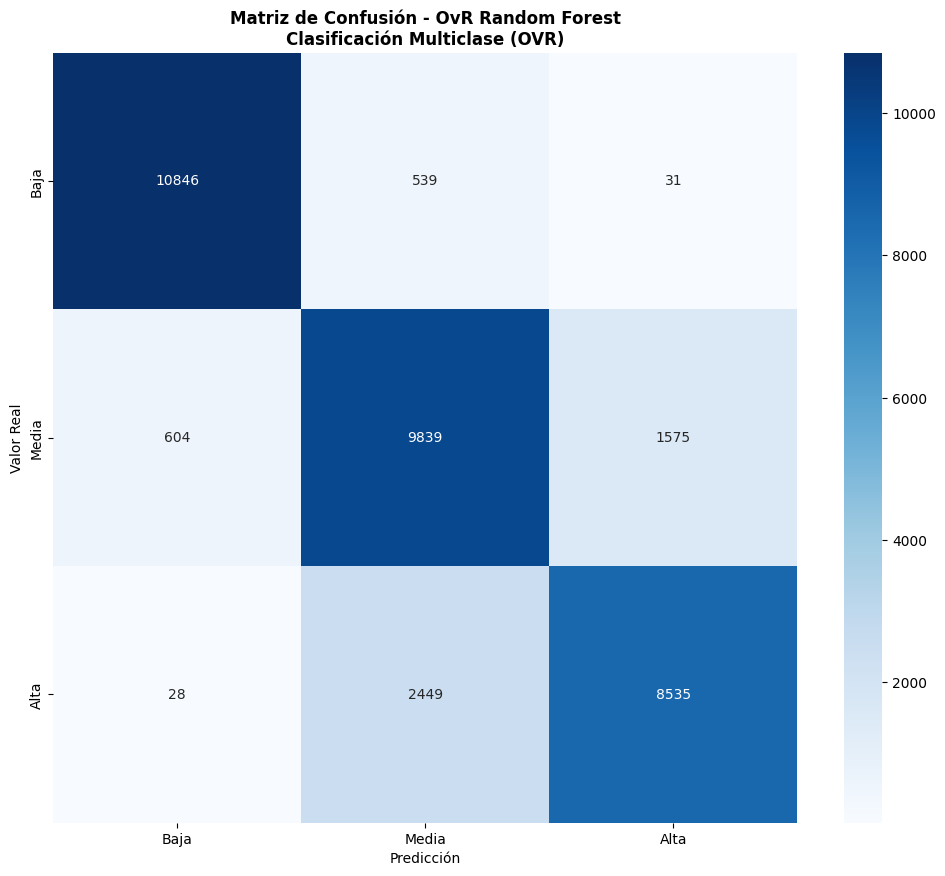

              precision    recall  f1-score   support

        Baja     0.9234    0.9347    0.9290     11416
       Media     0.7420    0.8013    0.7705     12018
        Alta     0.8373    0.7535    0.7932     11012

    accuracy                         0.8303     34446
   macro avg     0.8342    0.8299    0.8309     34446
weighted avg     0.8326    0.8303    0.8303     34446



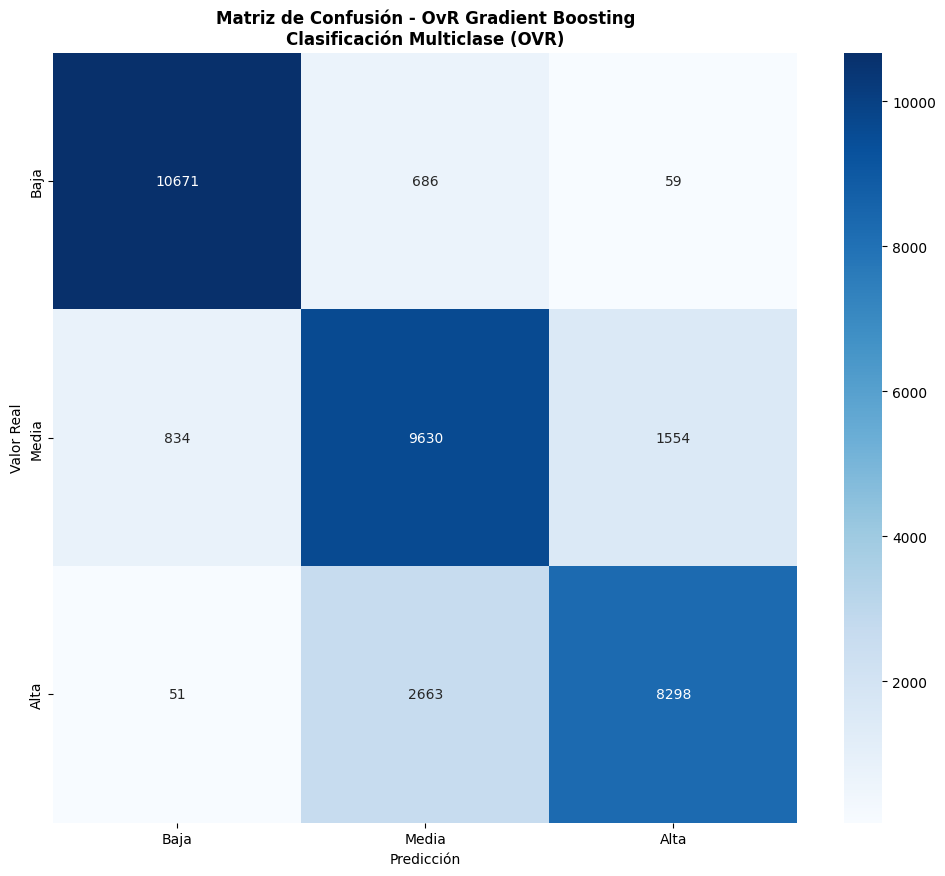

              precision    recall  f1-score   support

        Baja     0.9492    0.9416    0.9454     11416
       Media     0.7592    0.8322    0.7940     12018
        Alta     0.8492    0.7673    0.8062     11012

    accuracy                         0.8477     34446
   macro avg     0.8526    0.8470    0.8485     34446
weighted avg     0.8510    0.8477    0.8481     34446



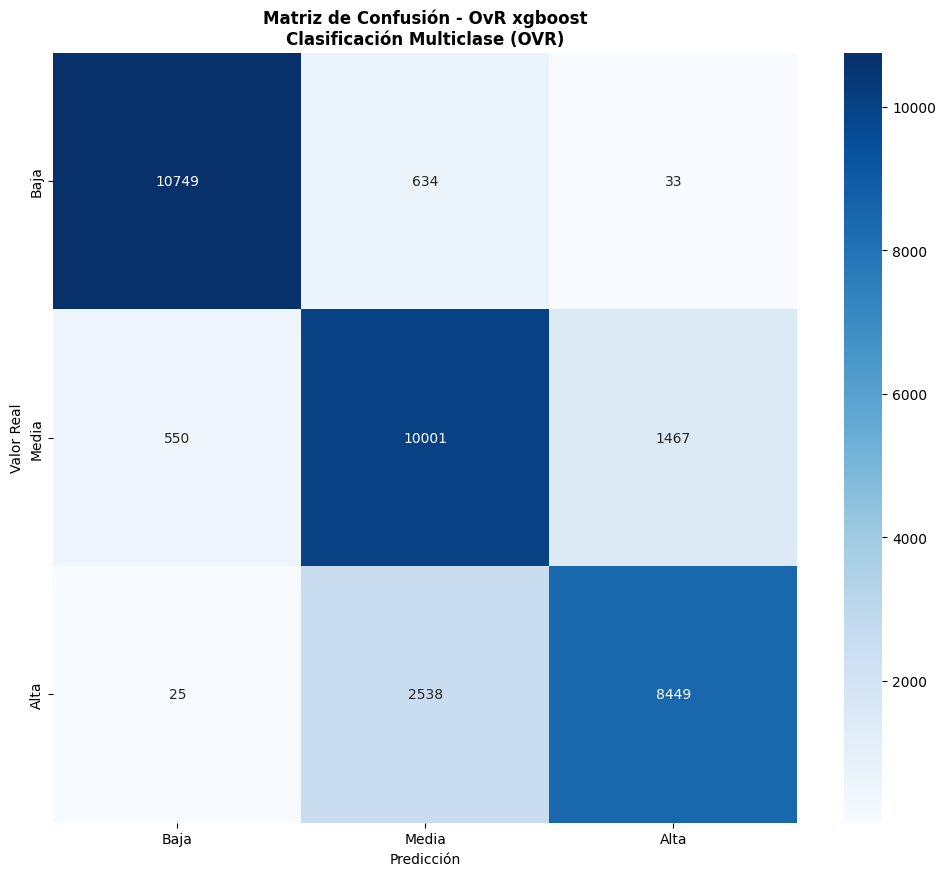

              precision    recall  f1-score   support

        Baja     0.8208    0.7878    0.8039     11416
       Media     0.7414    0.4368    0.5498     12018
        Alta     0.5753    0.8572    0.6885     11012

    accuracy                         0.6875     34446
   macro avg     0.7125    0.6939    0.6807     34446
weighted avg     0.7146    0.6875    0.6783     34446



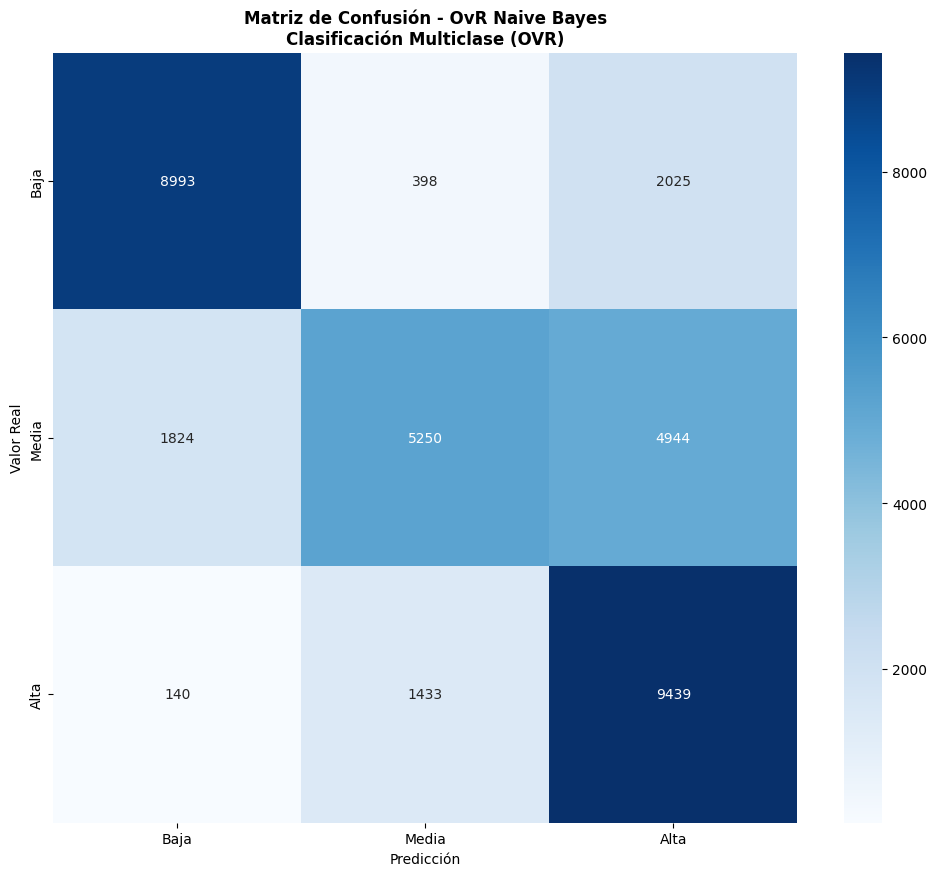

Entrenando OvR Logistic Regression...
   Completado - Accuracy: 0.6270, F1: 0.6155, Clasificadores: 5
Entrenando OvR Decision Tree...
   Completado - Accuracy: 0.7309, F1: 0.7315, Clasificadores: 5
Entrenando OvR Random Forest...
   Completado - Accuracy: 0.7486, F1: 0.7485, Clasificadores: 5
Entrenando OvR Gradient Boosting...
   Completado - Accuracy: 0.7225, F1: 0.7229, Clasificadores: 5
Entrenando OvR xgboost...
   Completado - Accuracy: 0.7476, F1: 0.7480, Clasificadores: 5
Entrenando OvR Naive Bayes...
   Completado - Accuracy: 0.5650, F1: 0.5544, Clasificadores: 5

RESULTADOS OvR - MULTICLASE (5 NIVELES):
                    Modelo  Accuracy  Precision  Recall  F1-Score  \
0        OvR Random Forest    0.7486     0.7510  0.7486    0.7485   
1              OvR xgboost    0.7476     0.7533  0.7476    0.7480   
2        OvR Decision Tree    0.7309     0.7393  0.7309    0.7315   
3    OvR Gradient Boosting    0.7225     0.7284  0.7225    0.7229   
4  OvR Logistic Regression    0.627

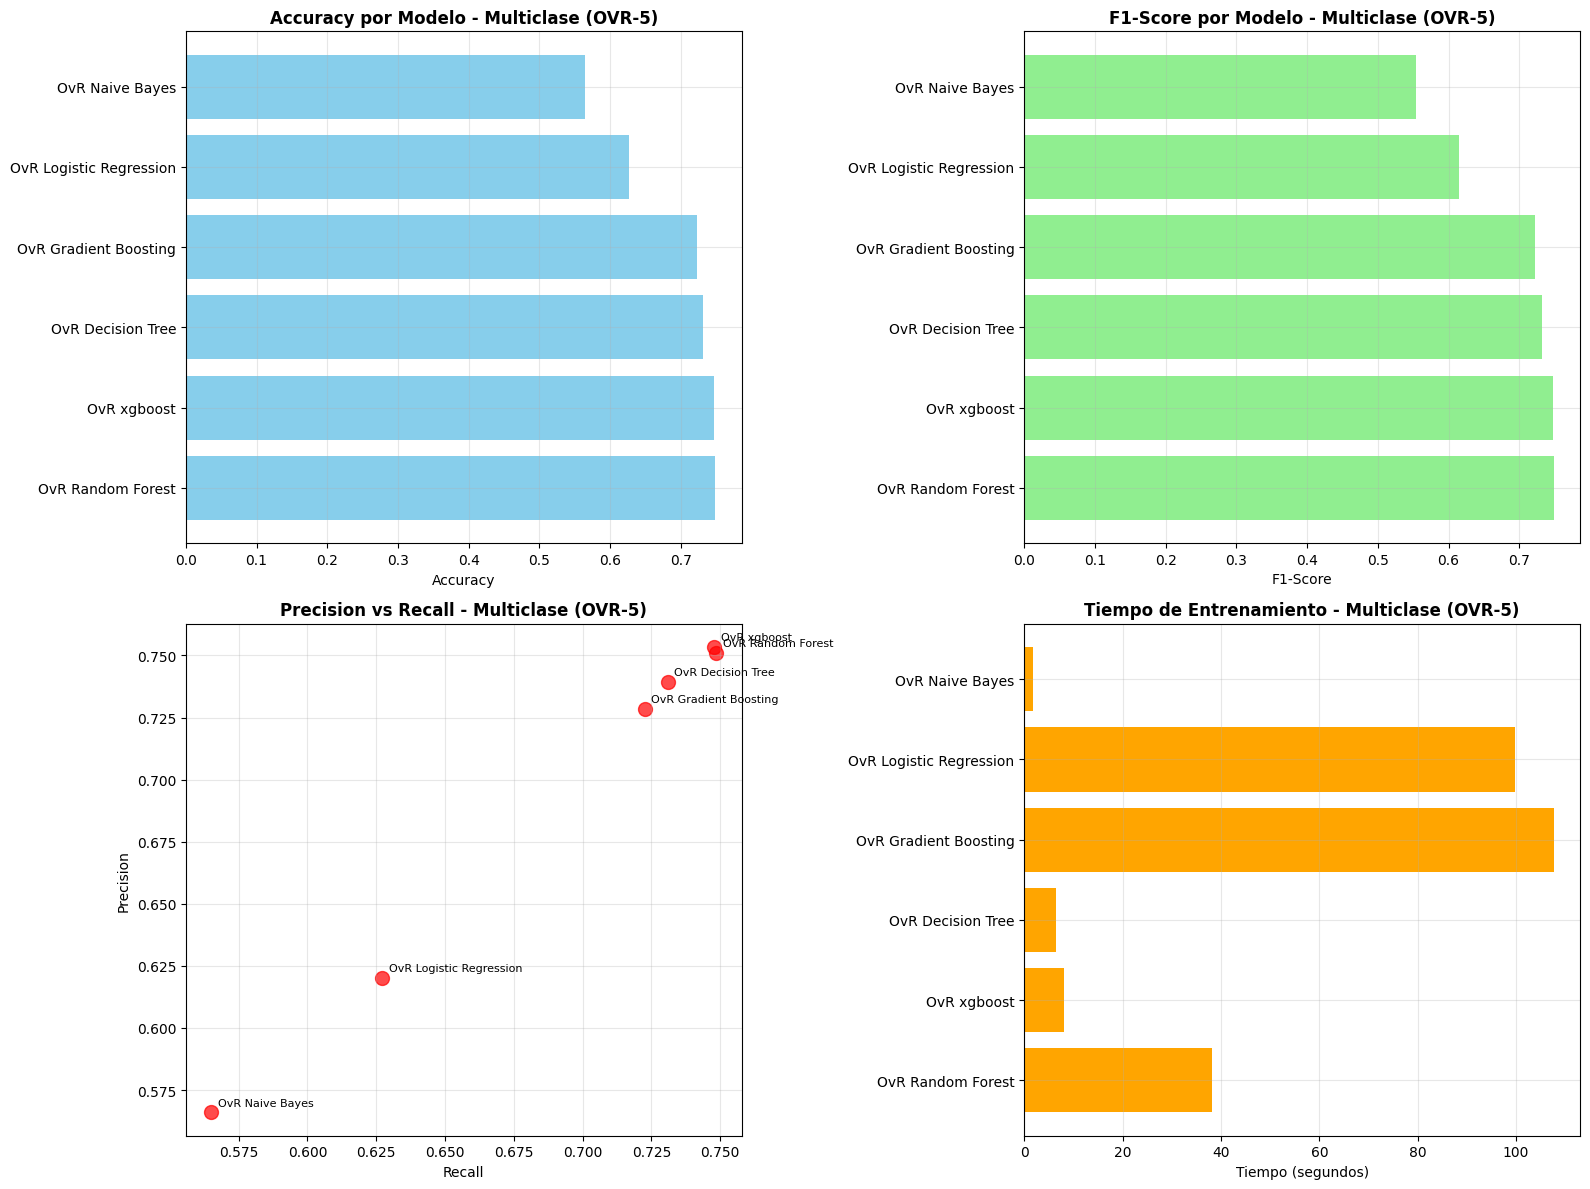

              precision    recall  f1-score   support

    Muy Baja     0.7654    0.9508    0.8481      7946
        Baja     0.6084    0.4393    0.5102      5836
       Media     0.5107    0.3742    0.4319      6918
        Alta     0.4759    0.5934    0.5282      6861
    Muy Alta     0.7155    0.7001    0.7077      6885

    accuracy                         0.6270     34446
   macro avg     0.6152    0.6116    0.6052     34446
weighted avg     0.6200    0.6270    0.6155     34446



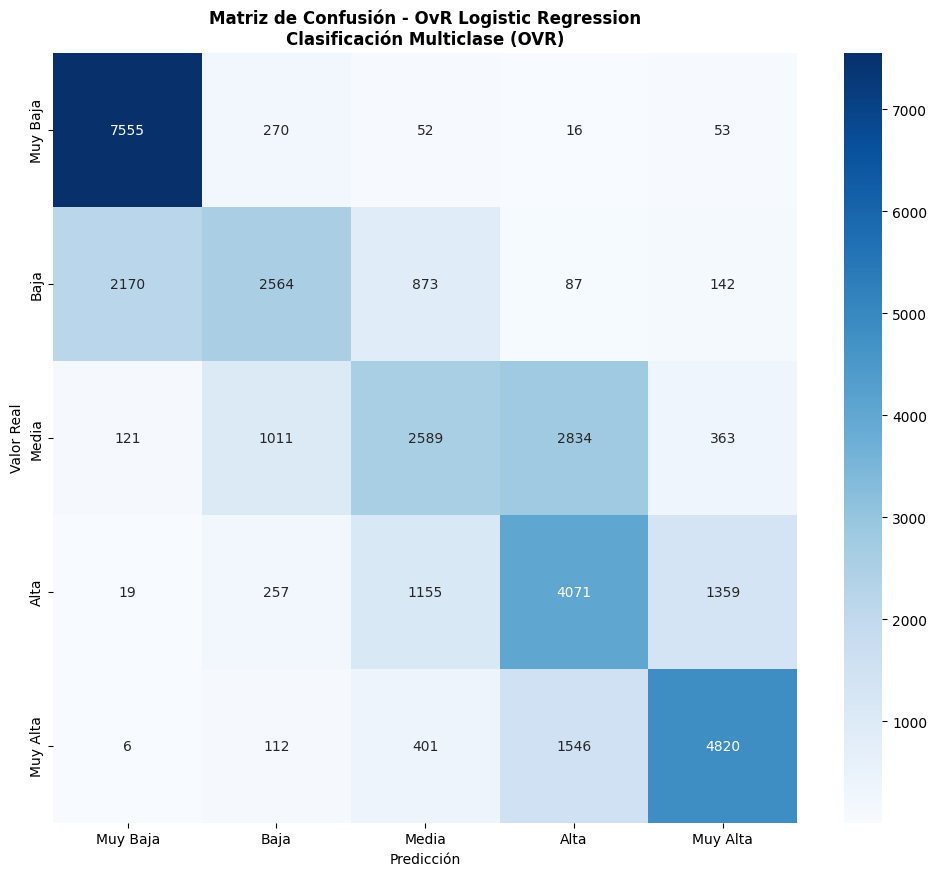

              precision    recall  f1-score   support

    Muy Baja     0.9229    0.9349    0.9289      7946
        Baja     0.7037    0.8089    0.7527      5836
       Media     0.5952    0.6545    0.6235      6918
        Alta     0.5854    0.5805    0.5829      6861
    Muy Alta     0.8558    0.6558    0.7425      6885

    accuracy                         0.7309     34446
   macro avg     0.7326    0.7269    0.7261     34446
weighted avg     0.7393    0.7309    0.7315     34446



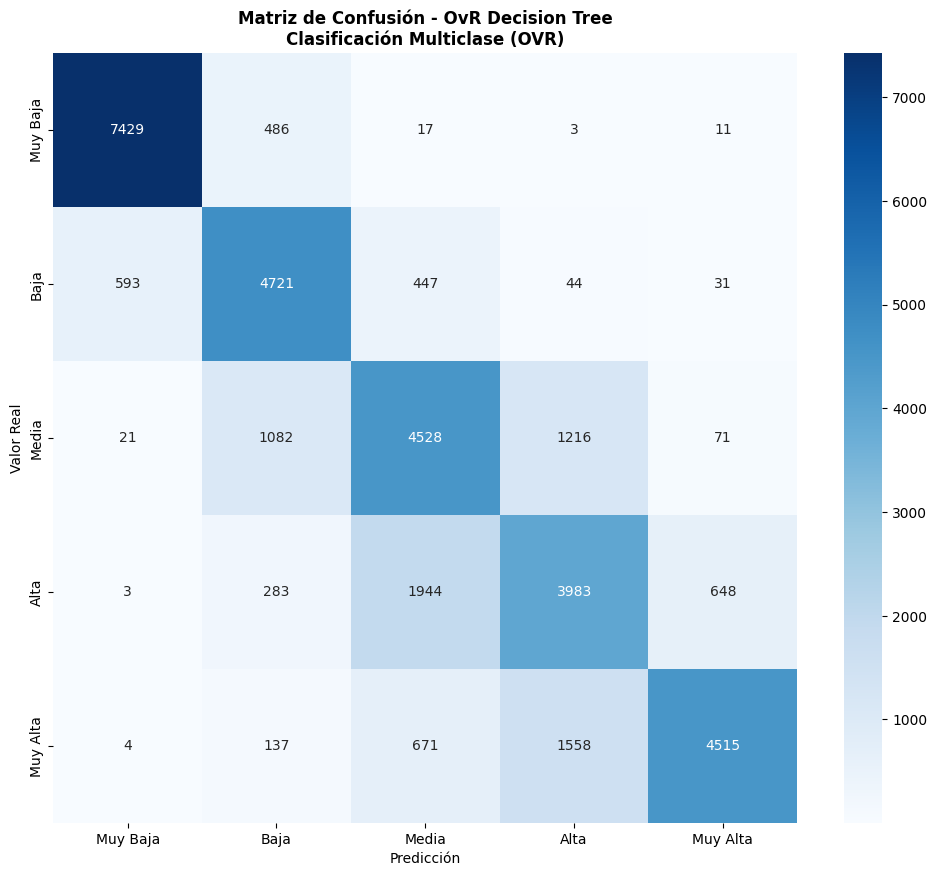

              precision    recall  f1-score   support

    Muy Baja     0.9353    0.9532    0.9442      7946
        Baja     0.7645    0.8136    0.7882      5836
       Media     0.6164    0.6751    0.6444      6918
        Alta     0.5980    0.5779    0.5878      6861
    Muy Alta     0.8144    0.7015    0.7537      6885

    accuracy                         0.7486     34446
   macro avg     0.7457    0.7442    0.7437     34446
weighted avg     0.7510    0.7486    0.7485     34446



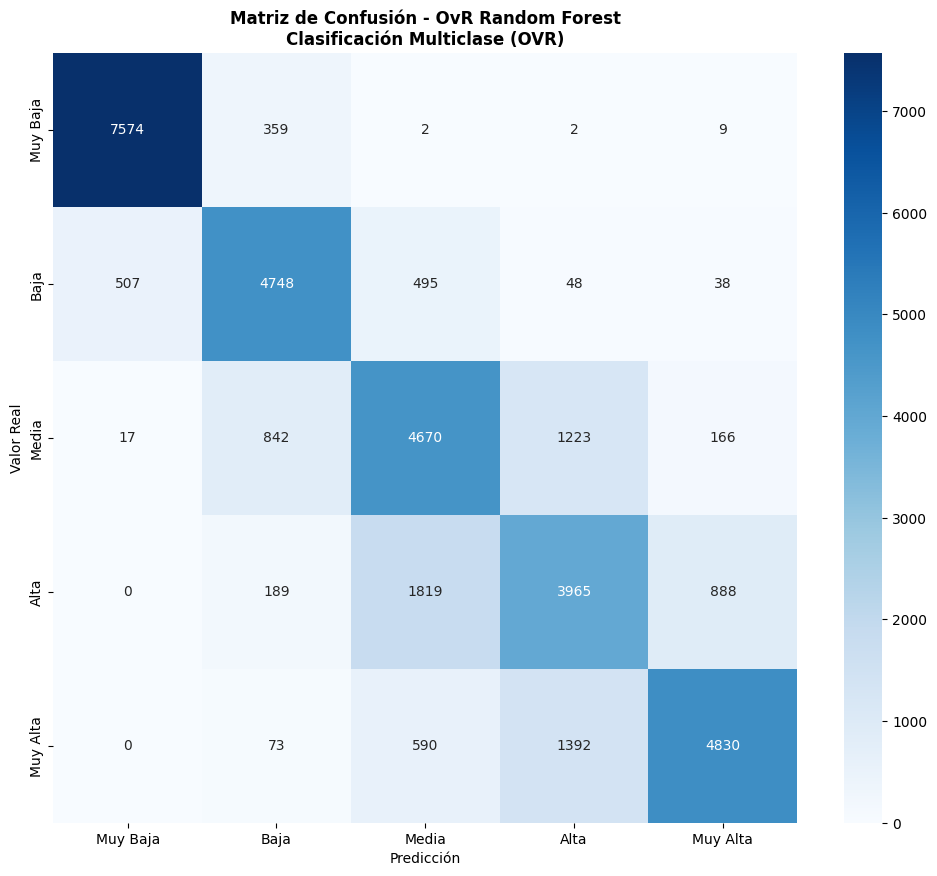

              precision    recall  f1-score   support

    Muy Baja     0.9127    0.9232    0.9179      7946
        Baja     0.6804    0.7834    0.7283      5836
       Media     0.5900    0.6492    0.6182      6918
        Alta     0.5926    0.5603    0.5760      6861
    Muy Alta     0.8311    0.6747    0.7447      6885

    accuracy                         0.7225     34446
   macro avg     0.7213    0.7181    0.7170     34446
weighted avg     0.7284    0.7225    0.7229     34446



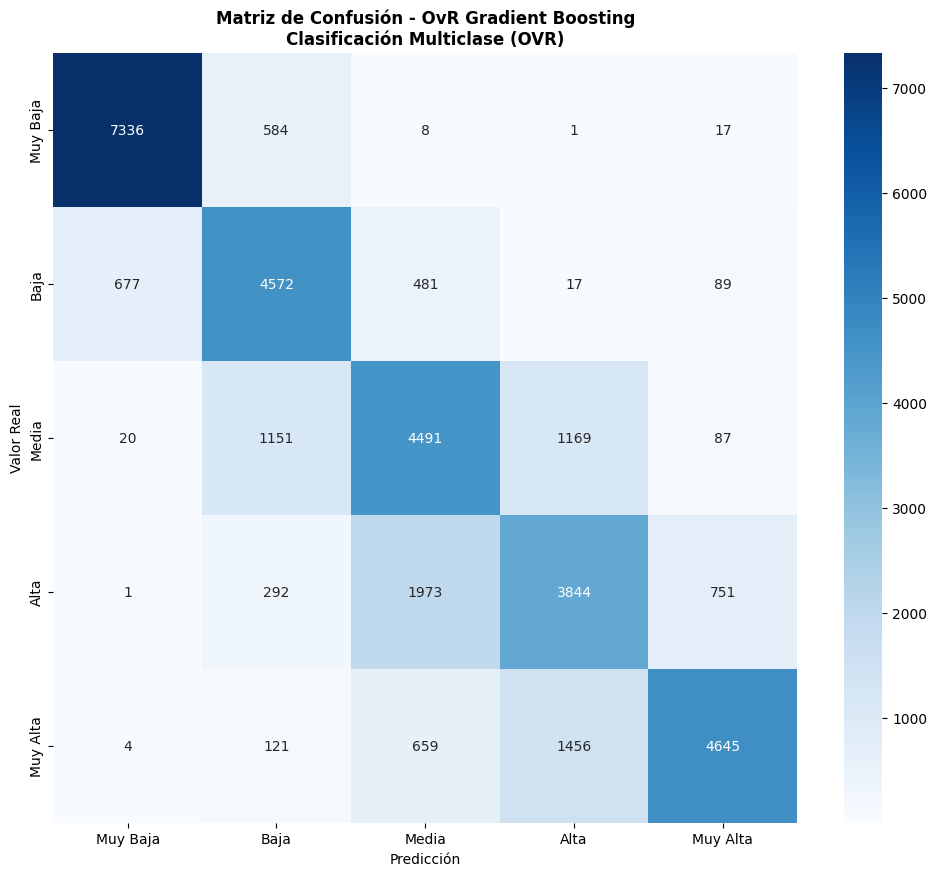

              precision    recall  f1-score   support

    Muy Baja     0.9326    0.9476    0.9401      7946
        Baja     0.7465    0.8137    0.7787      5836
       Media     0.6080    0.6868    0.6450      6918
        Alta     0.6046    0.5833    0.5938      6861
    Muy Alta     0.8465    0.6857    0.7577      6885

    accuracy                         0.7476     34446
   macro avg     0.7476    0.7434    0.7430     34446
weighted avg     0.7533    0.7476    0.7480     34446



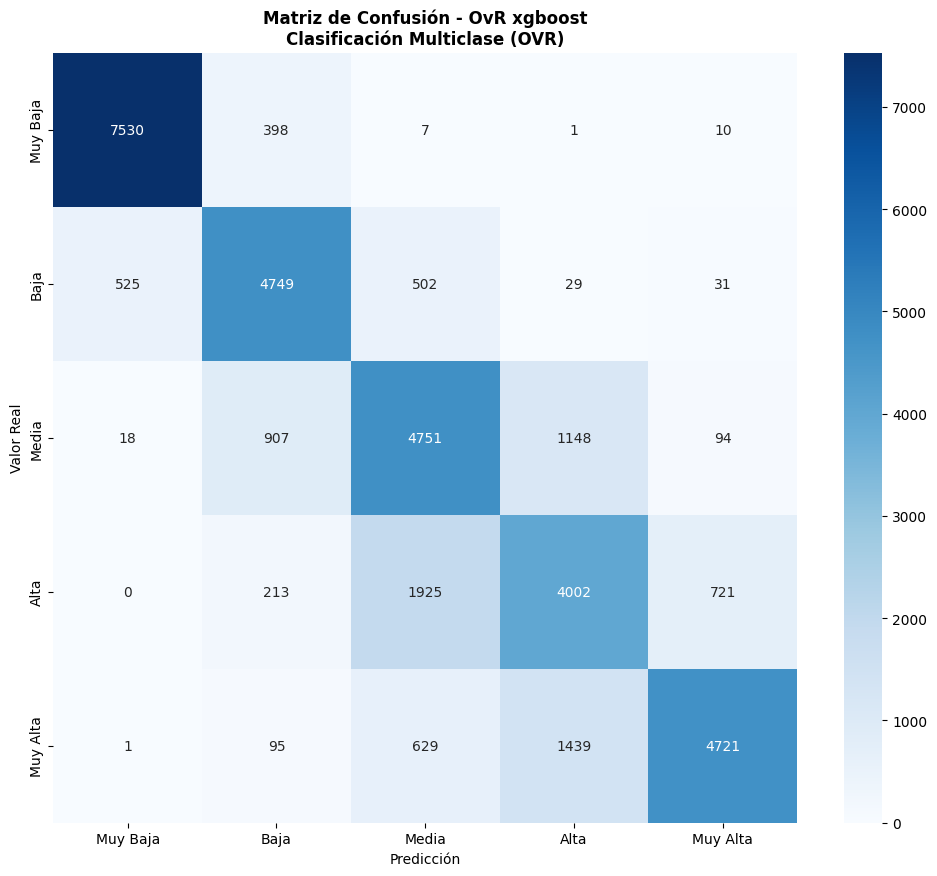

              precision    recall  f1-score   support

    Muy Baja     0.7322    0.7783    0.7545      7946
        Baja     0.5577    0.3588    0.4367      5836
       Media     0.5197    0.3435    0.4136      6918
        Alta     0.4518    0.5607    0.5004      6861
    Muy Alta     0.5415    0.7204    0.6183      6885

    accuracy                         0.5650     34446
   macro avg     0.5606    0.5523    0.5447     34446
weighted avg     0.5660    0.5650    0.5544     34446



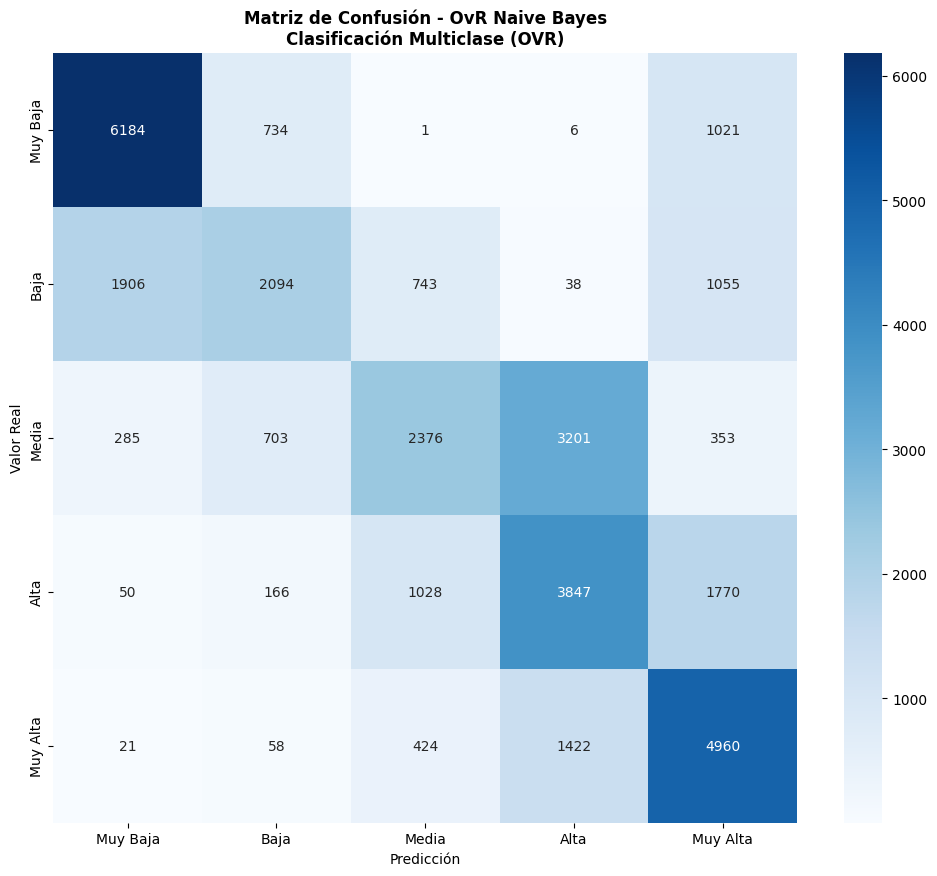


Estrategias OvR completadas


In [ ]:
# ESTRATEGIAS ONE-VS-REST (OvR)

ovr_compatible_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
     "xgboost":xgboost.XGBClassifier(random_state=42, objective='binary:logistic'),
    'Naive Bayes': GaussianNB(),
    'xgboost':xgboost.XGBClassifier(objective='binary:logistic')
}


def evaluate_ovr_model(base_model, X_train, X_test, y_train, y_test, model_name, task_type,s):
    """Evalúa un modelo usando estrategia One-vs-Rest"""
    
    ovr_model = OneVsRestClassifier(base_model, n_jobs=-1)
    
    print(f"Entrenando OvR {model_name}...")
    
    
    start_time = time.time()
    ovr_model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    
    start_time = time.time()
    X_test = s.transform(X_test)
    y_pred = ovr_model.predict(X_test)
    prediction_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results = {
        'model_name': f"OvR {model_name}",
        'strategy': 'OvR',
        'task_type': task_type,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'model_object': ovr_model,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'n_classifiers': len(ovr_model.estimators_)
    }
    
    print(f"   Completado - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Clasificadores: {len(ovr_model.estimators_)}")
    return results



ovr_multi3_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        result = evaluate_ovr_model(
            base_model=model,
            X_train=X_train_multi3,
            X_test=X_test_multi3,
            y_train=y_train_multi3,
            y_test=y_test_multi3,
            model_name=model_name,
            task_type='multiclass_3',
            s=scaler1
        )
        ovr_multi3_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")


ovr_multi3_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'N° Clasificadores': r['n_classifiers'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovr_multi3_results])

ovr_multi3_df = ovr_multi3_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (3 NIVELES):")

print(ovr_multi3_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovr_multi3_df['Modelo'], ovr_multi3_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVR)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovr_multi3_df['Modelo'], ovr_multi3_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVR)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovr_multi3_df['Recall'], ovr_multi3_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovr_multi3_df['Modelo']):
    axes[1,0].annotate(txt, (ovr_multi3_df['Recall'].iloc[i], ovr_multi3_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVR)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovr_multi3_df['Modelo'], ovr_multi3_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovr_multi3_results):
    plt.figure(figsize=(12, 10))
    cm = ovr_multi3_results[i]['confusion_matrix']
    name_ = ovr_multi3_results[i]['model_name']
    class_names_5 = [ 'Baja', 'Media', 'Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVR)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi3, ovr_multi3_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



##########################################################################################################

ovr_multi5_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        result = evaluate_ovr_model(
            base_model=model,
            X_train=X_train_multi5,
            X_test=X_test_multi5,
            y_train=y_train_multi5,
            y_test=y_test_multi5,
            model_name=model_name,
            task_type='multiclass_5',
            s=scaler2
        )
        ovr_multi5_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")

ovr_multi5_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'N° Clasificadores': r['n_classifiers'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovr_multi5_results])

ovr_multi5_df = ovr_multi5_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (5 NIVELES):")
print(ovr_multi5_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovr_multi5_df['Modelo'], ovr_multi5_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVR-5)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovr_multi5_df['Modelo'], ovr_multi5_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVR-5)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovr_multi5_df['Recall'], ovr_multi5_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovr_multi5_df['Modelo']):
    axes[1,0].annotate(txt, (ovr_multi5_df['Recall'].iloc[i], ovr_multi5_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVR-5)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovr_multi5_df['Modelo'], ovr_multi5_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR-5)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovr_multi5_results):
    plt.figure(figsize=(12, 10))
    cm = ovr_multi5_results[i]['confusion_matrix']
    name_ = ovr_multi5_results[i]['model_name']
    class_names_5 = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVR)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi5, ovr_multi5_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



print(f"\nEstrategias OvR completadas")

Entrenando OvR Logistic Regression...
   Completado - Accuracy: 0.8098, F1: 0.8099, Clasificadores: 3
Entrenando OvR Decision Tree...
   Completado - Accuracy: 0.8388, F1: 0.8390, Clasificadores: 3
Entrenando OvR Random Forest...
   Completado - Accuracy: 0.8488, F1: 0.8487, Clasificadores: 3
Entrenando OvR Gradient Boosting...
   Completado - Accuracy: 0.8323, F1: 0.8324, Clasificadores: 3
Entrenando OvR xgboost...
   Completado - Accuracy: 0.8466, F1: 0.8469, Clasificadores: 3
Entrenando OvR Naive Bayes...
   Completado - Accuracy: 0.7061, F1: 0.7030, Clasificadores: 3

RESULTADOS OvR - MULTICLASE (3 NIVELES):
                    Modelo  Accuracy  Precision  Recall  F1-Score  \
0        OvR Random Forest    0.8488     0.8504  0.8488    0.8487   
1              OvR xgboost    0.8466     0.8496  0.8466    0.8469   
2        OvR Decision Tree    0.8388     0.8421  0.8388    0.8390   
3    OvR Gradient Boosting    0.8323     0.8351  0.8323    0.8324   
4  OvR Logistic Regression    0.809

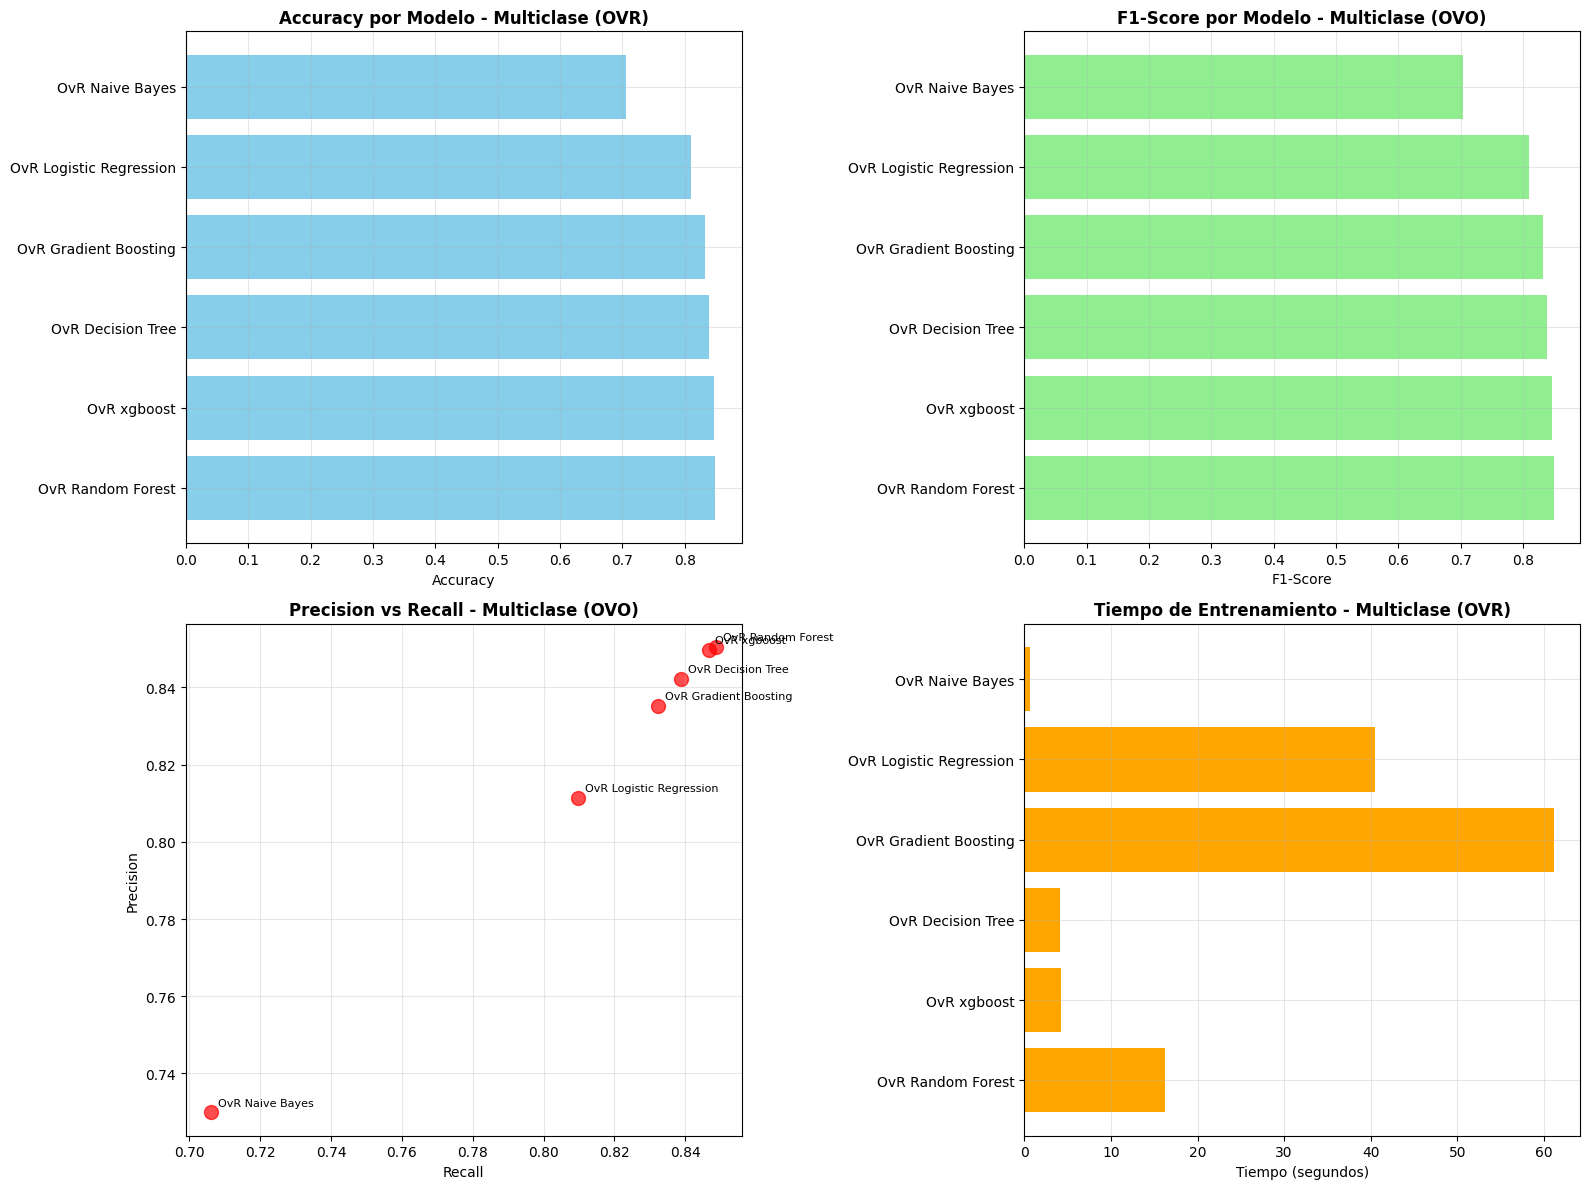

              precision    recall  f1-score   support

        Baja     0.9014    0.9173    0.9093     11416
       Media     0.7193    0.7624    0.7402     12018
        Alta     0.8185    0.7500    0.7828     11012

    accuracy                         0.8098     34446
   macro avg     0.8131    0.8099    0.8108     34446
weighted avg     0.8114    0.8098    0.8099     34446



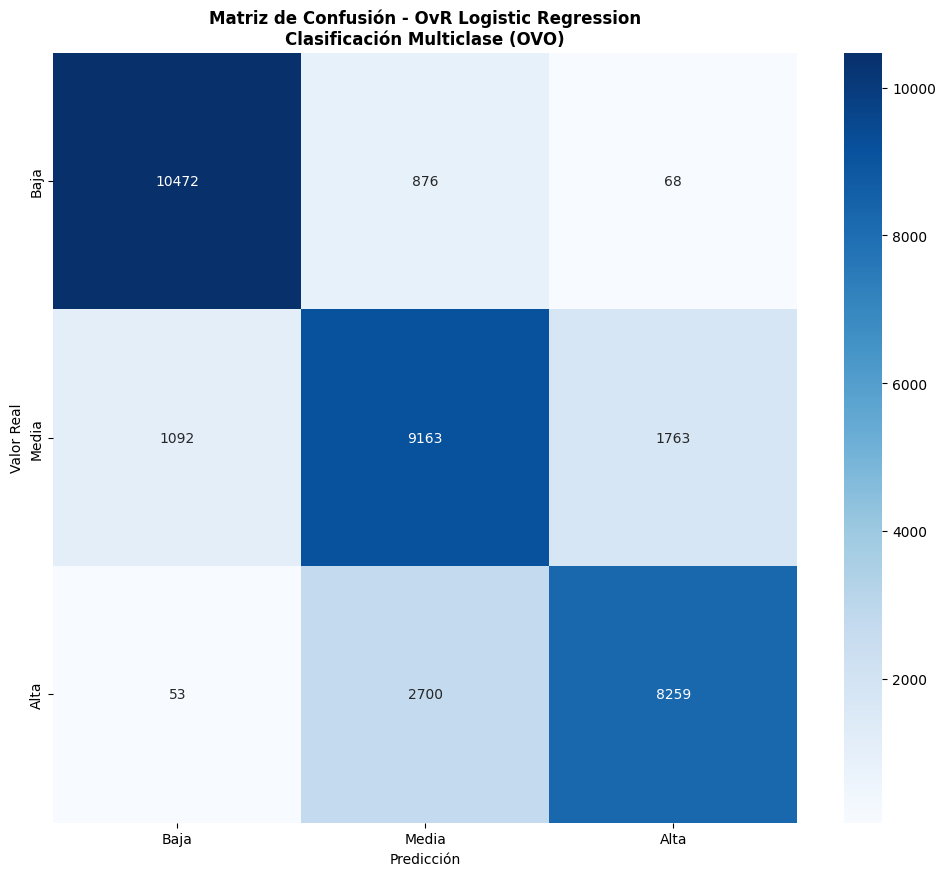

              precision    recall  f1-score   support

        Baja     0.9410    0.9409    0.9410     11416
       Media     0.7476    0.8221    0.7831     12018
        Alta     0.8428    0.7513    0.7944     11012

    accuracy                         0.8388     34446
   macro avg     0.8438    0.8381    0.8395     34446
weighted avg     0.8421    0.8388    0.8390     34446



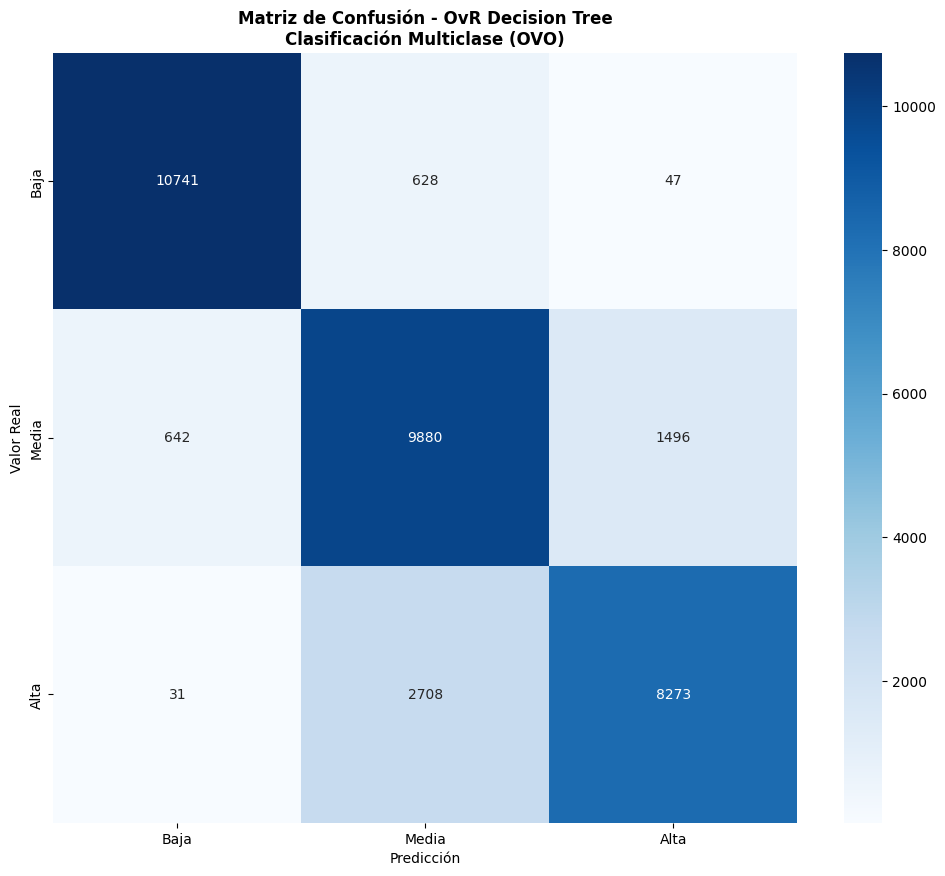

              precision    recall  f1-score   support

        Baja     0.9426    0.9529    0.9477     11416
       Media     0.7669    0.8214    0.7932     12018
        Alta     0.8460    0.7708    0.8067     11012

    accuracy                         0.8488     34446
   macro avg     0.8518    0.8484    0.8492     34446
weighted avg     0.8504    0.8488    0.8487     34446



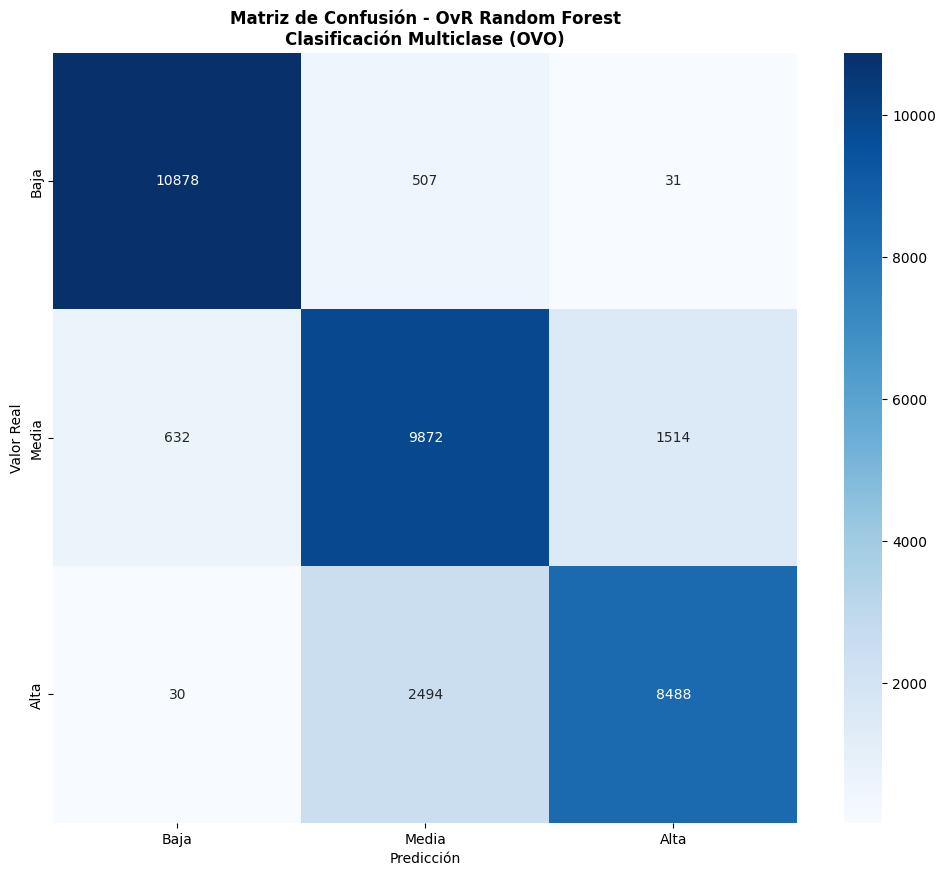

              precision    recall  f1-score   support

        Baja     0.9266    0.9361    0.9313     11416
       Media     0.7420    0.8075    0.7734     12018
        Alta     0.8418    0.7518    0.7943     11012

    accuracy                         0.8323     34446
   macro avg     0.8368    0.8318    0.8330     34446
weighted avg     0.8351    0.8323    0.8324     34446



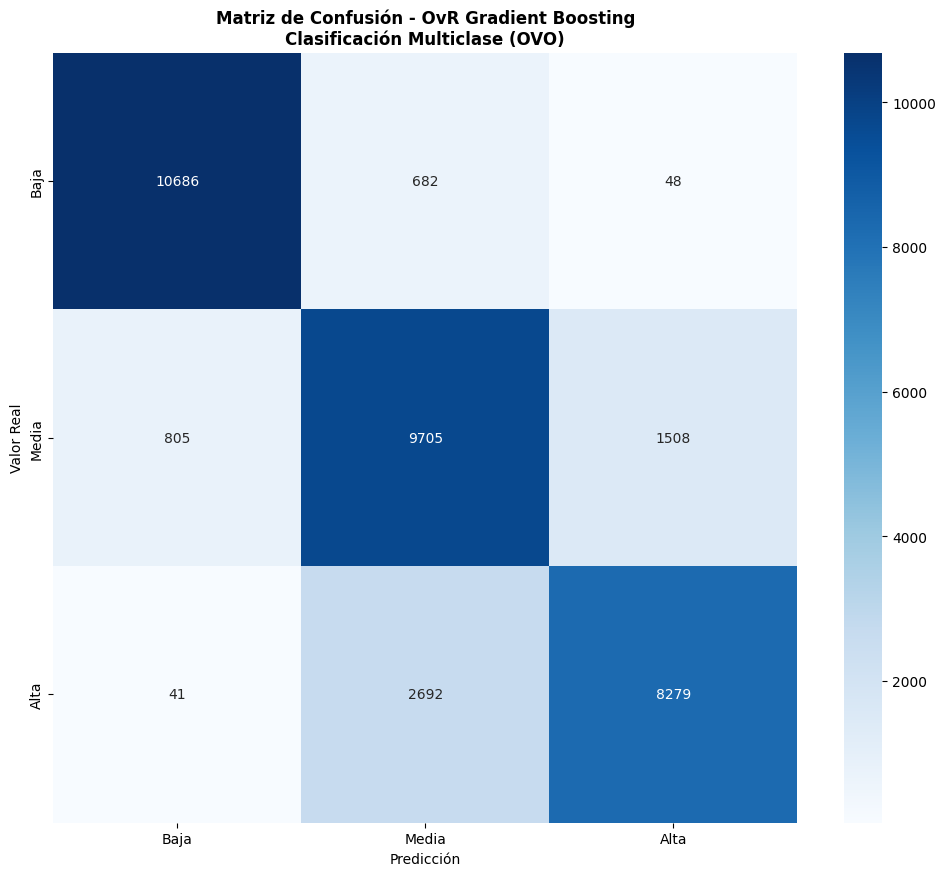

              precision    recall  f1-score   support

        Baja     0.9483    0.9439    0.9461     11416
       Media     0.7583    0.8284    0.7918     12018
        Alta     0.8470    0.7655    0.8042     11012

    accuracy                         0.8466     34446
   macro avg     0.8512    0.8460    0.8474     34446
weighted avg     0.8496    0.8466    0.8469     34446



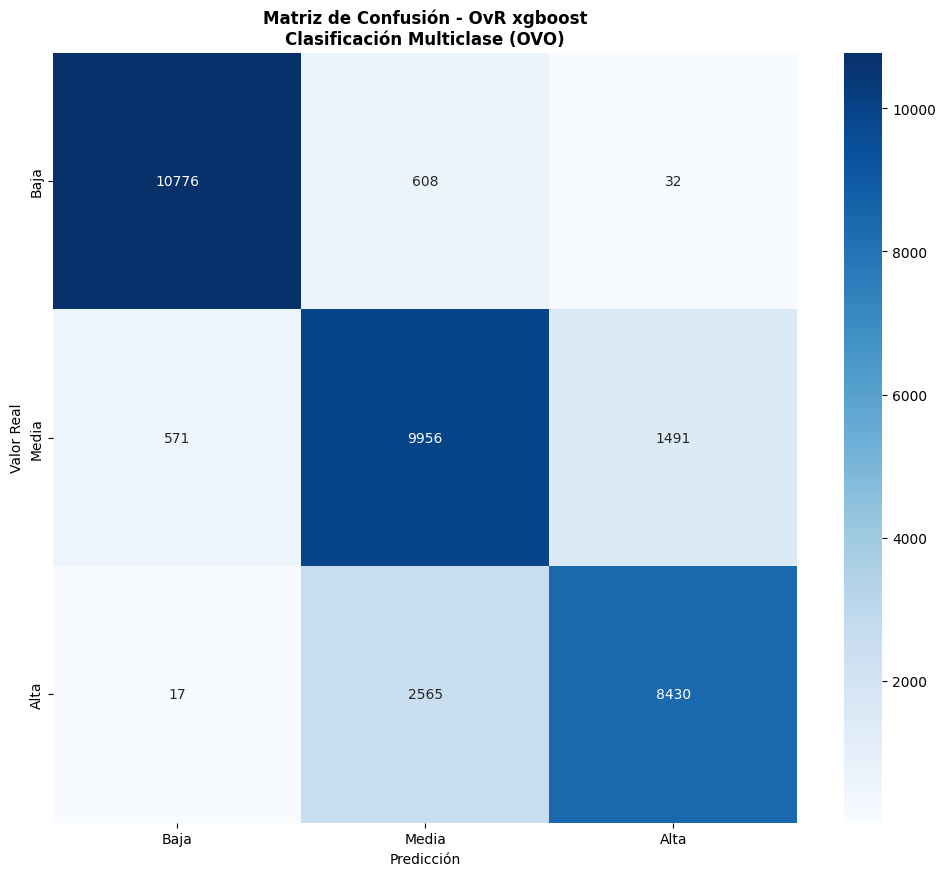

              precision    recall  f1-score   support

        Baja     0.8695    0.7870    0.8262     11416
       Media     0.7274    0.5042    0.5955     12018
        Alta     0.5879    0.8427    0.6926     11012

    accuracy                         0.7061     34446
   macro avg     0.7283    0.7113    0.7048     34446
weighted avg     0.7299    0.7061    0.7030     34446



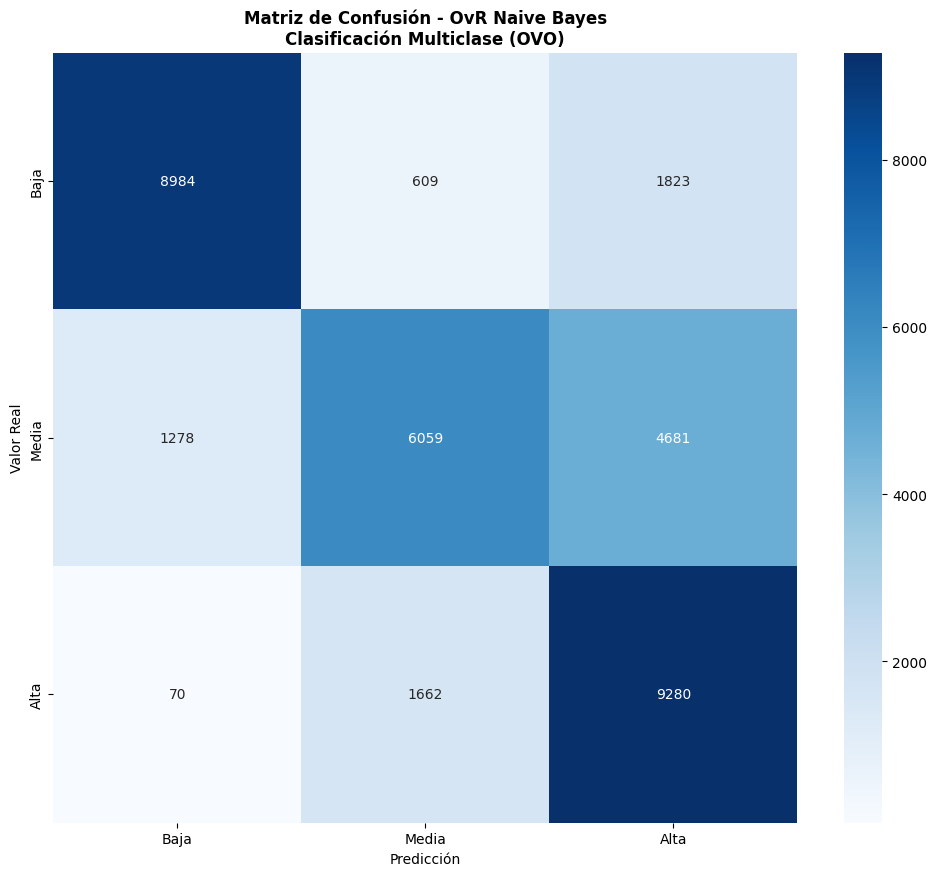

Entrenando OvR Logistic Regression...
   Completado - Accuracy: 0.6750, F1: 0.6735, Clasificadores: 10
Entrenando OvR Decision Tree...
   Completado - Accuracy: 0.7284, F1: 0.7298, Clasificadores: 10
Entrenando OvR Random Forest...
   Completado - Accuracy: 0.7493, F1: 0.7493, Clasificadores: 10
Entrenando OvR Gradient Boosting...
   Completado - Accuracy: 0.7273, F1: 0.7282, Clasificadores: 10
Entrenando OvR xgboost...
   Completado - Accuracy: 0.7464, F1: 0.7468, Clasificadores: 10
Entrenando OvR Naive Bayes...
   Completado - Accuracy: 0.5781, F1: 0.5760, Clasificadores: 10

RESULTADOS OvR - MULTICLASE (5 NIVELES):
                    Modelo  Accuracy  Precision  Recall  F1-Score  \
0        OvR Random Forest    0.7493     0.7529  0.7493    0.7493   
1              OvR xgboost    0.7464     0.7509  0.7464    0.7468   
2        OvR Decision Tree    0.7284     0.7377  0.7284    0.7298   
3    OvR Gradient Boosting    0.7273     0.7347  0.7273    0.7282   
4  OvR Logistic Regression   

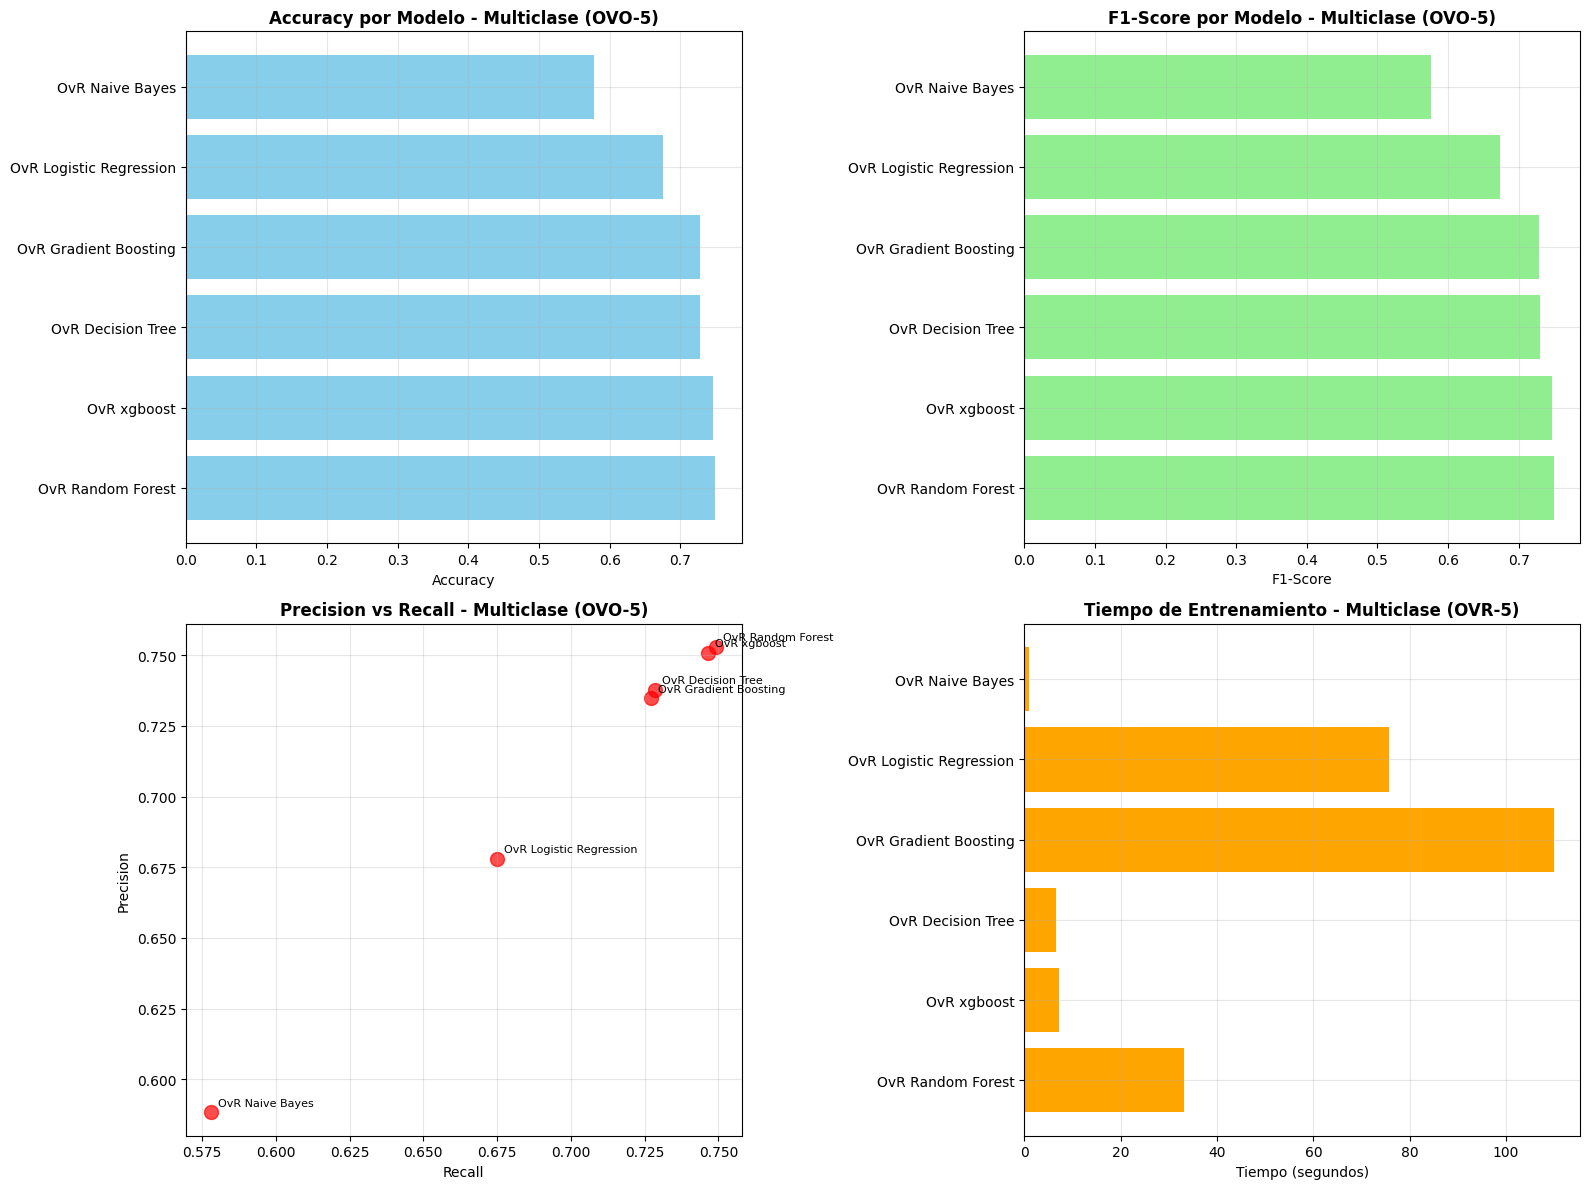

              precision    recall  f1-score   support

    Muy Baja     0.8226    0.9234    0.8701      7946
        Baja     0.6535    0.5636    0.6052      5836
       Media     0.5431    0.6236    0.5805      6918
        Alta     0.5487    0.5413    0.5450      6861
    Muy Alta     0.7954    0.6678    0.7260      6885

    accuracy                         0.6750     34446
   macro avg     0.6726    0.6639    0.6654     34446
weighted avg     0.6778    0.6750    0.6735     34446



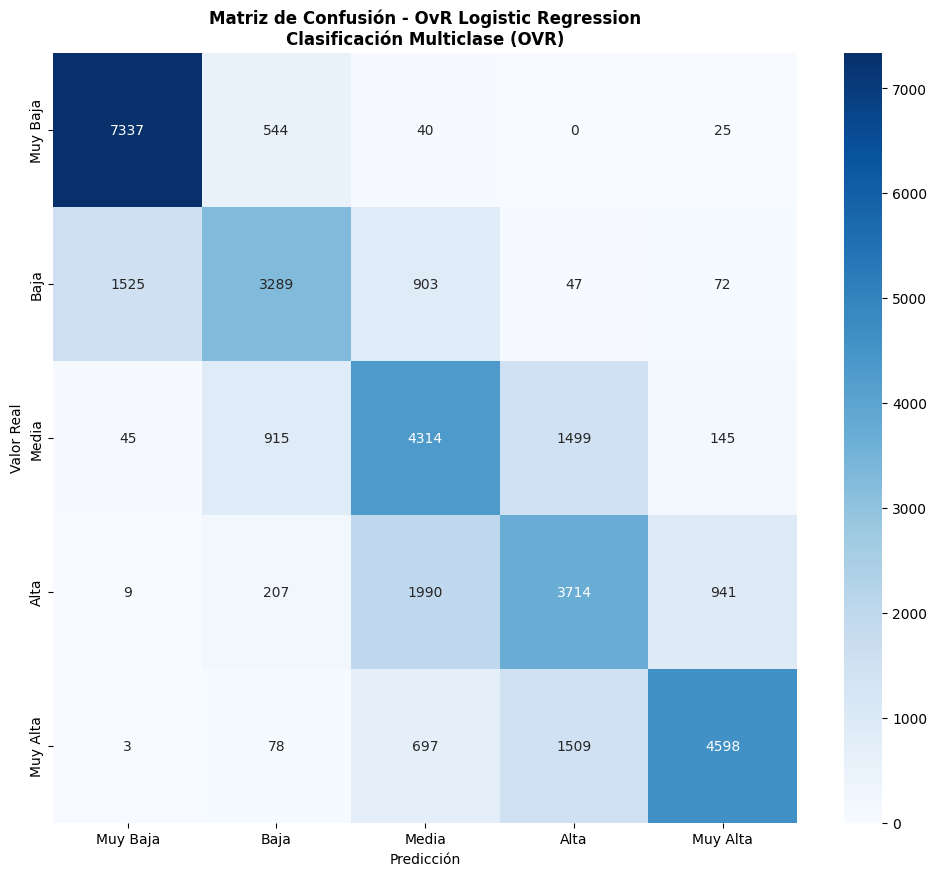

              precision    recall  f1-score   support

    Muy Baja     0.9263    0.9368    0.9315      7946
        Baja     0.7238    0.7872    0.7542      5836
       Media     0.5845    0.6552    0.6179      6918
        Alta     0.5733    0.5861    0.5796      6861
    Muy Alta     0.8496    0.6533    0.7386      6885

    accuracy                         0.7284     34446
   macro avg     0.7315    0.7237    0.7244     34446
weighted avg     0.7377    0.7284    0.7298     34446



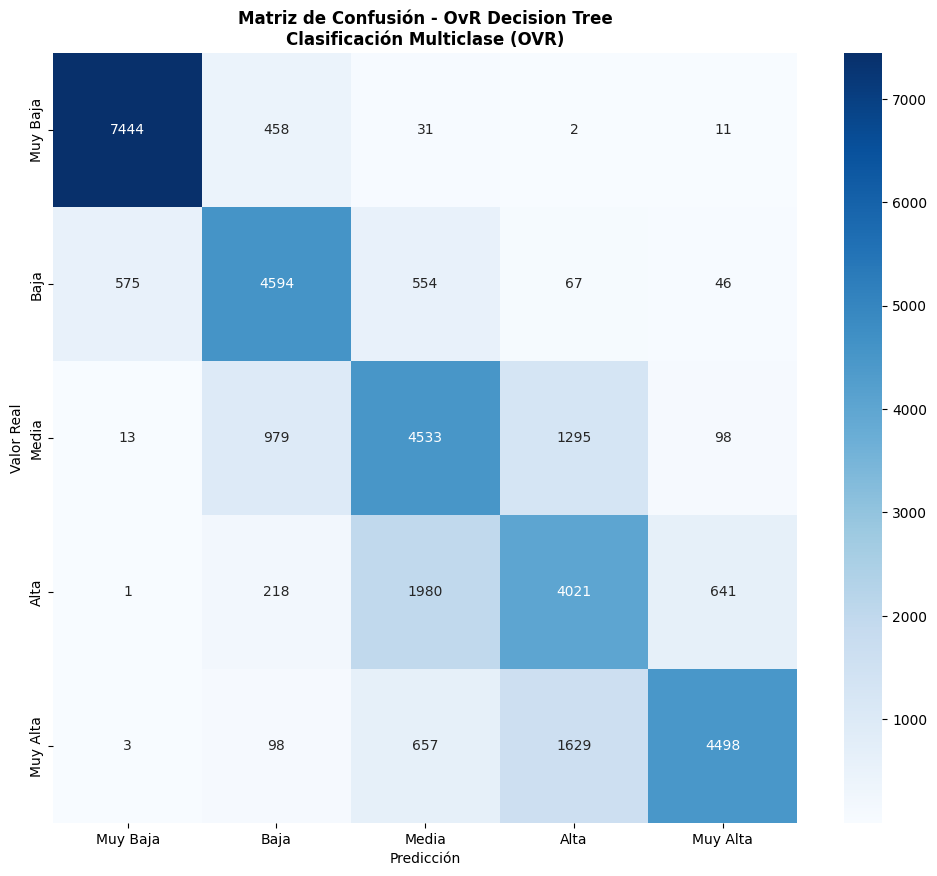

              precision    recall  f1-score   support

    Muy Baja     0.9343    0.9539    0.9440      7946
        Baja     0.7652    0.8153    0.7894      5836
       Media     0.6162    0.6886    0.6504      6918
        Alta     0.5992    0.5799    0.5894      6861
    Muy Alta     0.8235    0.6870    0.7491      6885

    accuracy                         0.7493     34446
   macro avg     0.7477    0.7450    0.7445     34446
weighted avg     0.7529    0.7493    0.7493     34446



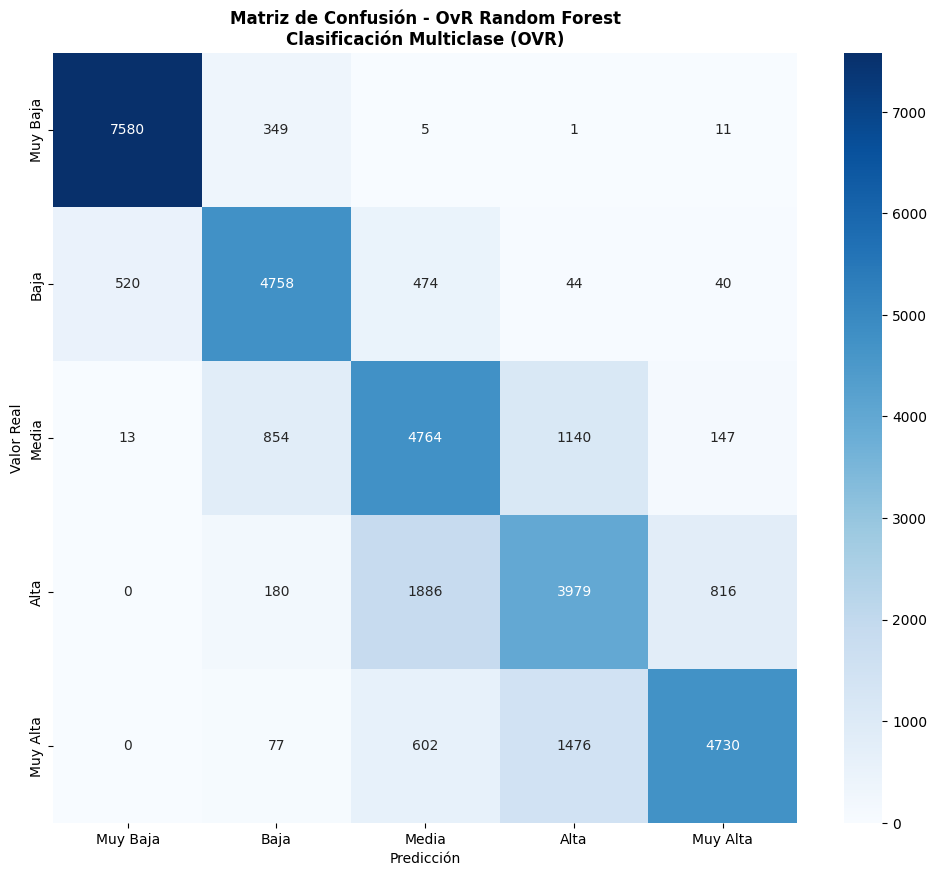

              precision    recall  f1-score   support

    Muy Baja     0.9200    0.9220    0.9210      7946
        Baja     0.6956    0.7851    0.7377      5836
       Media     0.5875    0.6680    0.6251      6918
        Alta     0.5967    0.5646    0.5802      6861
    Muy Alta     0.8395    0.6752    0.7485      6885

    accuracy                         0.7273     34446
   macro avg     0.7279    0.7230    0.7225     34446
weighted avg     0.7347    0.7273    0.7282     34446



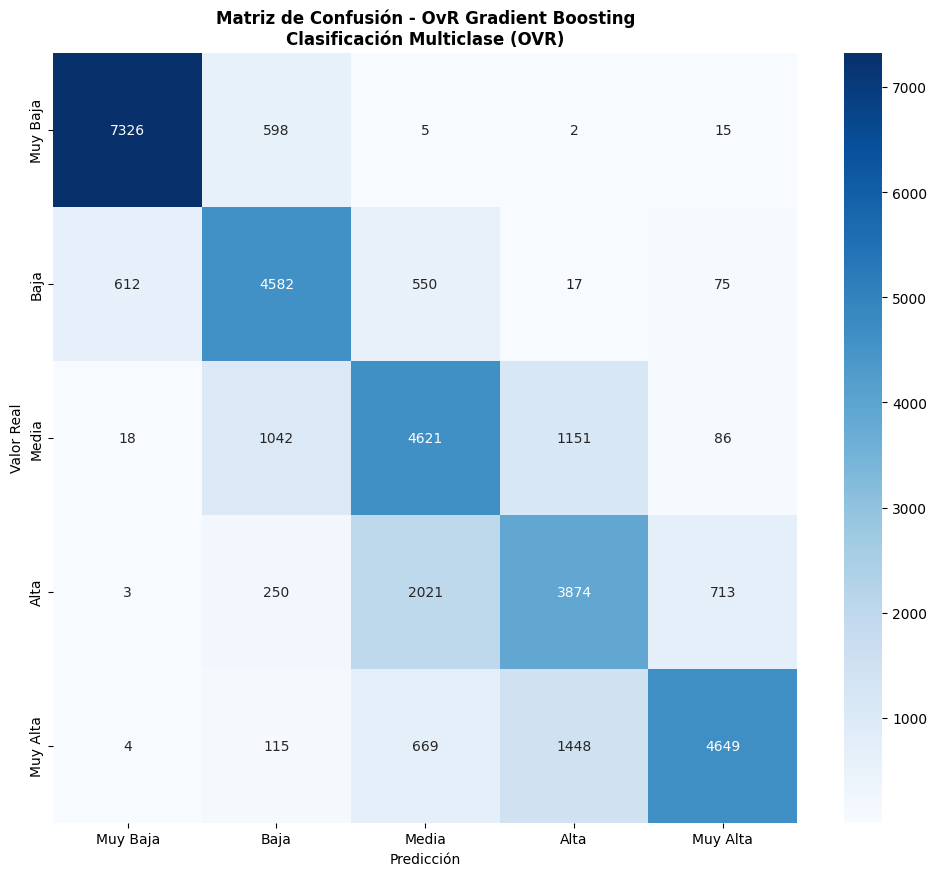

              precision    recall  f1-score   support

    Muy Baja     0.9361    0.9476    0.9418      7946
        Baja     0.7599    0.8069    0.7827      5836
       Media     0.6057    0.6886    0.6445      6918
        Alta     0.5991    0.5729    0.5858      6861
    Muy Alta     0.8266    0.6938    0.7544      6885

    accuracy                         0.7464     34446
   macro avg     0.7455    0.7420    0.7418     34446
weighted avg     0.7509    0.7464    0.7468     34446



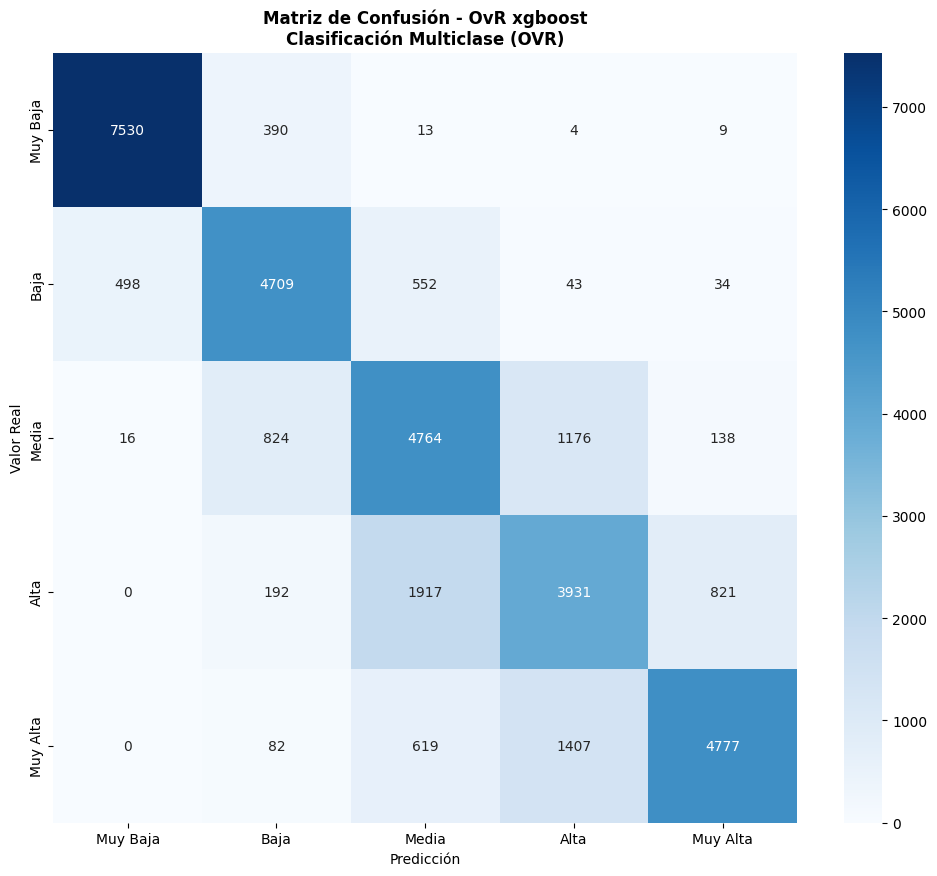

              precision    recall  f1-score   support

    Muy Baja     0.8102    0.7124    0.7582      7946
        Baja     0.5193    0.4937    0.5061      5836
       Media     0.5267    0.3534    0.4230      6918
        Alta     0.4612    0.6129    0.5263      6861
    Muy Alta     0.5791    0.6857    0.6279      6885

    accuracy                         0.5781     34446
   macro avg     0.5793    0.5716    0.5683     34446
weighted avg     0.5883    0.5781    0.5760     34446



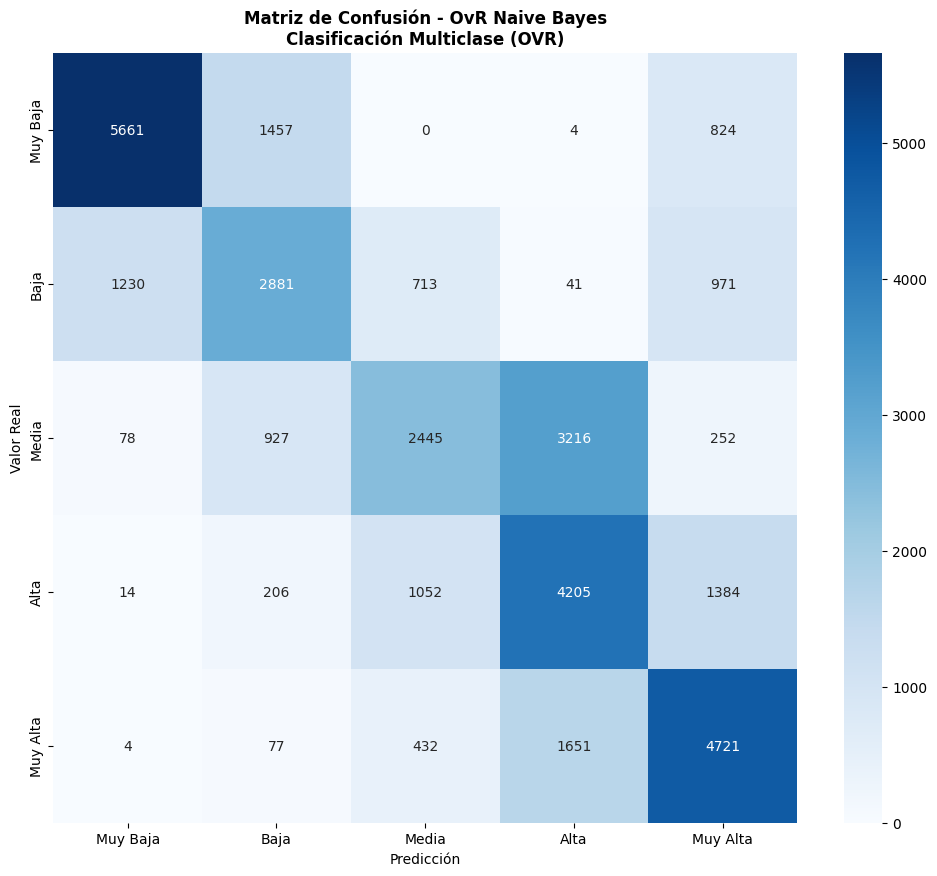


Estrategias OvR completadas


In [ ]:
# ESTRATEGIAS ONE-VS-REST (OvO)

ovo_compatible_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'Naive Bayes': GaussianNB(),
    'xgboost':xgboost.XGBClassifier(objective='binary:logistic')
}


def evaluate_ovo_model(base_model, X_train, X_test, y_train, y_test, model_name, task_type,sc):
    """Evalúa un modelo usando estrategia One-vs-One"""
    
    ovr_model = OneVsOneClassifier(base_model, n_jobs=-1)
    
    print(f"Entrenando OvR {model_name}...")
    
    
    start_time = time.time()
    ovr_model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    
    start_time = time.time()
    X_test = sc.transform(X_test)
    y_pred = ovr_model.predict(X_test)
    prediction_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results = {
        'model_name': f"OvR {model_name}",
        'strategy': 'OvR',
        'task_type': task_type,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'model_object': ovr_model,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'n_classifiers': len(ovr_model.estimators_)
    }
    
    print(f"   Completado - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Clasificadores: {len(ovr_model.estimators_)}")
    return results



ovo_multi3_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        result = evaluate_ovo_model(
            base_model=model,
            X_train=X_train_multi3,
            X_test=X_test_multi3,
            y_train=y_train_multi3,
            y_test=y_test_multi3,
            model_name=model_name,
            task_type='multiclass_3',
            sc=scaler1
        )
        ovo_multi3_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")


ovo_multi3_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'N° Clasificadores': r['n_classifiers'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovo_multi3_results])

ovo_multi3_df = ovo_multi3_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (3 NIVELES):")

print(ovo_multi3_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovo_multi3_df['Modelo'], ovo_multi3_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVR)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovo_multi3_df['Modelo'], ovo_multi3_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVO)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovo_multi3_df['Recall'], ovo_multi3_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovo_multi3_df['Modelo']):
    axes[1,0].annotate(txt, (ovo_multi3_df['Recall'].iloc[i], ovo_multi3_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVO)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovo_multi3_df['Modelo'], ovo_multi3_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovo_multi3_results):
    plt.figure(figsize=(12, 10))
    cm = ovo_multi3_results[i]['confusion_matrix']
    name_ = ovo_multi3_results[i]['model_name']
    class_names_5 = ['Baja', 'Media', 'Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVO)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi3, ovo_multi3_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



##########################################################################################################

ovo_multi5_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        result = evaluate_ovo_model(
            base_model=model,
            X_train=X_train_multi5,
            X_test=X_test_multi5,
            y_train=y_train_multi5,
            y_test=y_test_multi5,
            model_name=model_name,
            task_type='multiclass_5',
            sc=scaler2
        )
        ovo_multi5_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")

ovo_multi5_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'N° Clasificadores': r['n_classifiers'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovo_multi5_results])

ovo_multi5_df = ovo_multi5_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (5 NIVELES):")
print(ovo_multi5_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovo_multi5_df['Modelo'], ovo_multi5_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVO-5)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovo_multi5_df['Modelo'], ovo_multi5_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVO-5)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovo_multi5_df['Recall'], ovo_multi5_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovo_multi5_df['Modelo']):
    axes[1,0].annotate(txt, (ovo_multi5_df['Recall'].iloc[i], ovo_multi5_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVO-5)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovo_multi5_df['Modelo'], ovo_multi5_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR-5)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovo_multi5_results):
    plt.figure(figsize=(12, 10))
    cm = ovo_multi5_results[i]['confusion_matrix']
    name_ = ovo_multi5_results[i]['model_name']
    class_names_5 = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVR)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi5, ovo_multi5_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



print(f"\nEstrategias OvR completadas")

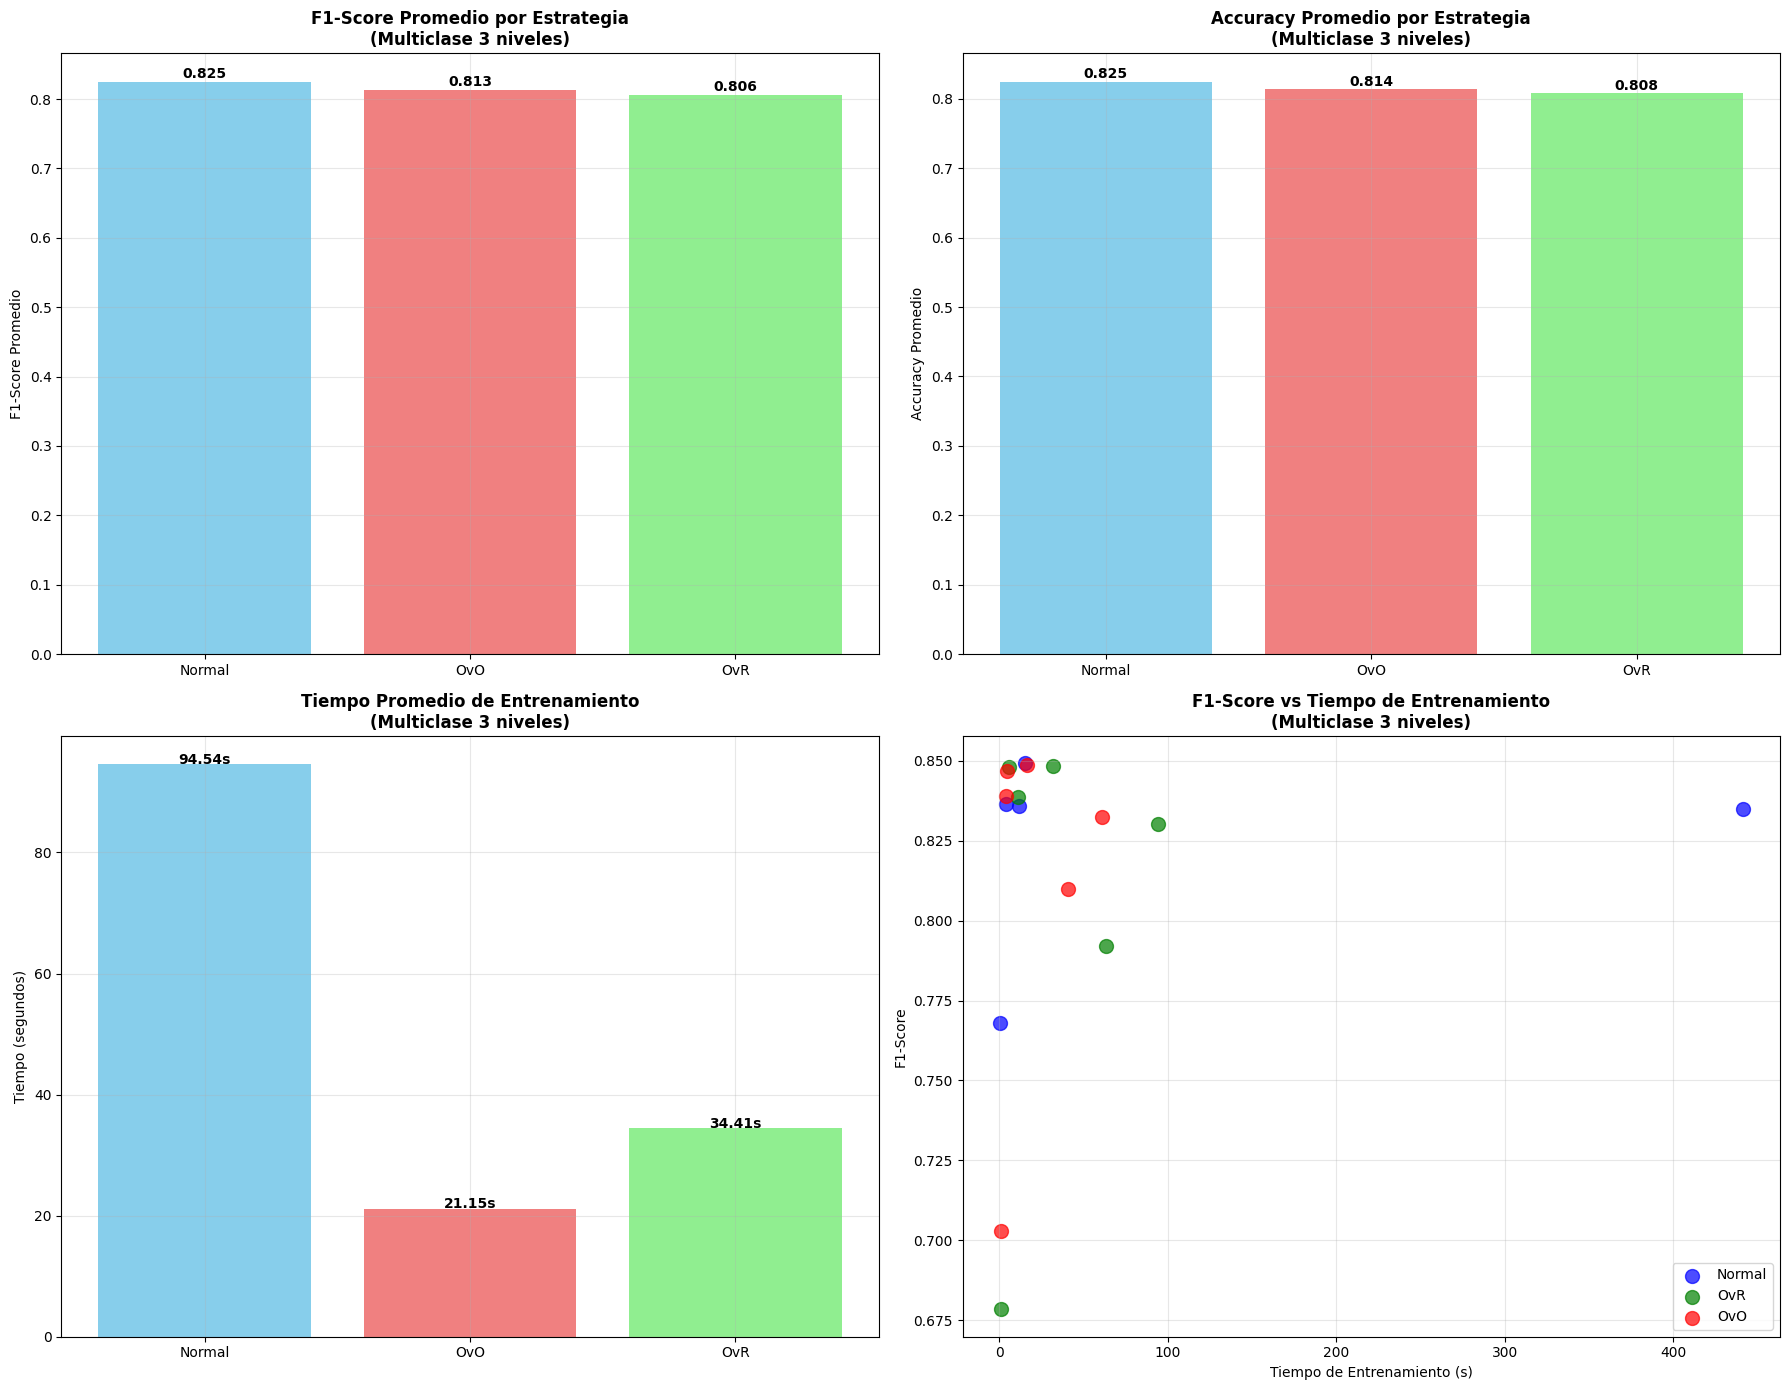

           F1-Score                 Accuracy                  \
               mean     std     max     mean     std     max   
Estrategia                                                     
Normal       0.8249  0.0324  0.8493   0.8247  0.0324  0.8494   
OvO          0.8133  0.0558  0.8487   0.8137  0.0546  0.8488   
OvR          0.8060  0.0659  0.8483   0.8080  0.0621  0.8483   

           Tiempo Entrenamiento            
                           mean       std  
Estrategia                                 
Normal                  94.5358  194.0489  
OvO                     21.1541   24.4387  
OvR                     34.4139   37.1790  

MEJORES MODELOS POR ESTRATEGIA (3 NIVELES):
Normal:
   Modelo: Random Forest
   F1-Score: 0.8493
   Accuracy: 0.8494
   Tiempo: 15.07s

OvR:
   Modelo: Random Forest
   F1-Score: 0.8483
   Accuracy: 0.8483
   Tiempo: 31.61s

OvO:
   Modelo: Random Forest
   F1-Score: 0.8487
   Accuracy: 0.8488
   Tiempo: 16.25s


Comparación completada para clasifi

In [ ]:



all_multi3_results = []


for result in multiclass3_results: 
    all_multi3_results.append({
        'Modelo': result['model_name'],
        'Estrategia': 'Normal',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })


for result in ovr_multi3_results:
    all_multi3_results.append({
        'Modelo': result['model_name'].replace('OvR ', ''),
        'Estrategia': 'OvR',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })
for result in ovo_multi3_results:
    all_multi3_results.append({
        'Modelo': result['model_name'].replace('OvR ', ''),
        'Estrategia': 'OvO',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })
comparison_multi3_df = pd.DataFrame(all_multi3_results)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))


strategy_f1_3 = comparison_multi3_df.groupby('Estrategia')['F1-Score'].mean()
axes[0,0].bar(strategy_f1_3.index, strategy_f1_3.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0,0].set_title('F1-Score Promedio por Estrategia\n(Multiclase 3 niveles)', fontweight='bold')
axes[0,0].set_ylabel('F1-Score Promedio')
axes[0,0].grid(True, alpha=0.3)
for i, v in enumerate(strategy_f1_3.values):
    axes[0,0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

strategy_acc_3 = comparison_multi3_df.groupby('Estrategia')['Accuracy'].mean()
axes[0,1].bar(strategy_acc_3.index, strategy_acc_3.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0,1].set_title('Accuracy Promedio por Estrategia\n(Multiclase 3 niveles)', fontweight='bold')
axes[0,1].set_ylabel('Accuracy Promedio')
axes[0,1].grid(True, alpha=0.3)
for i, v in enumerate(strategy_acc_3.values):
    axes[0,1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

strategy_time_3 = comparison_multi3_df.groupby('Estrategia')['Tiempo Entrenamiento'].mean()
axes[1,0].bar(strategy_time_3.index, strategy_time_3.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1,0].set_title('Tiempo Promedio de Entrenamiento\n(Multiclase 3 niveles)', fontweight='bold')
axes[1,0].set_ylabel('Tiempo (segundos)')
axes[1,0].grid(True, alpha=0.3)
for i, v in enumerate(strategy_time_3.values):
    axes[1,0].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontweight='bold')


colors_map = {'Normal': 'blue', 'OvO': 'red', 'OvR': 'green'}
for strategy in comparison_multi3_df['Estrategia'].unique():
    data = comparison_multi3_df[comparison_multi3_df['Estrategia'] == strategy]
    axes[1,1].scatter(data['Tiempo Entrenamiento'], data['F1-Score'], 
                     label=strategy, color=colors_map[strategy], s=100, alpha=0.7)

axes[1,1].set_title('F1-Score vs Tiempo de Entrenamiento\n(Multiclase 3 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo de Entrenamiento (s)')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


summary_3_levels = comparison_multi3_df.groupby('Estrategia').agg({
    'F1-Score': ['mean', 'std', 'max'],
    'Accuracy': ['mean', 'std', 'max'],
    'Tiempo Entrenamiento': ['mean', 'std']
}).round(4)

print(summary_3_levels)


print(f"\nMEJORES MODELOS POR ESTRATEGIA (3 NIVELES):")
print("="*50)
for strategy in comparison_multi3_df['Estrategia'].unique():
    best_model = comparison_multi3_df[comparison_multi3_df['Estrategia'] == strategy].loc[
        comparison_multi3_df[comparison_multi3_df['Estrategia'] == strategy]['F1-Score'].idxmax()
    ]
    print(f"{strategy}:")
    print(f"   Modelo: {best_model['Modelo']}")
    print(f"   F1-Score: {best_model['F1-Score']:.4f}")
    print(f"   Accuracy: {best_model['Accuracy']:.4f}")
    print(f"   Tiempo: {best_model['Tiempo Entrenamiento']:.2f}s")
    print()

print(f"\nComparación completada para clasificación multiclase (3 niveles)")

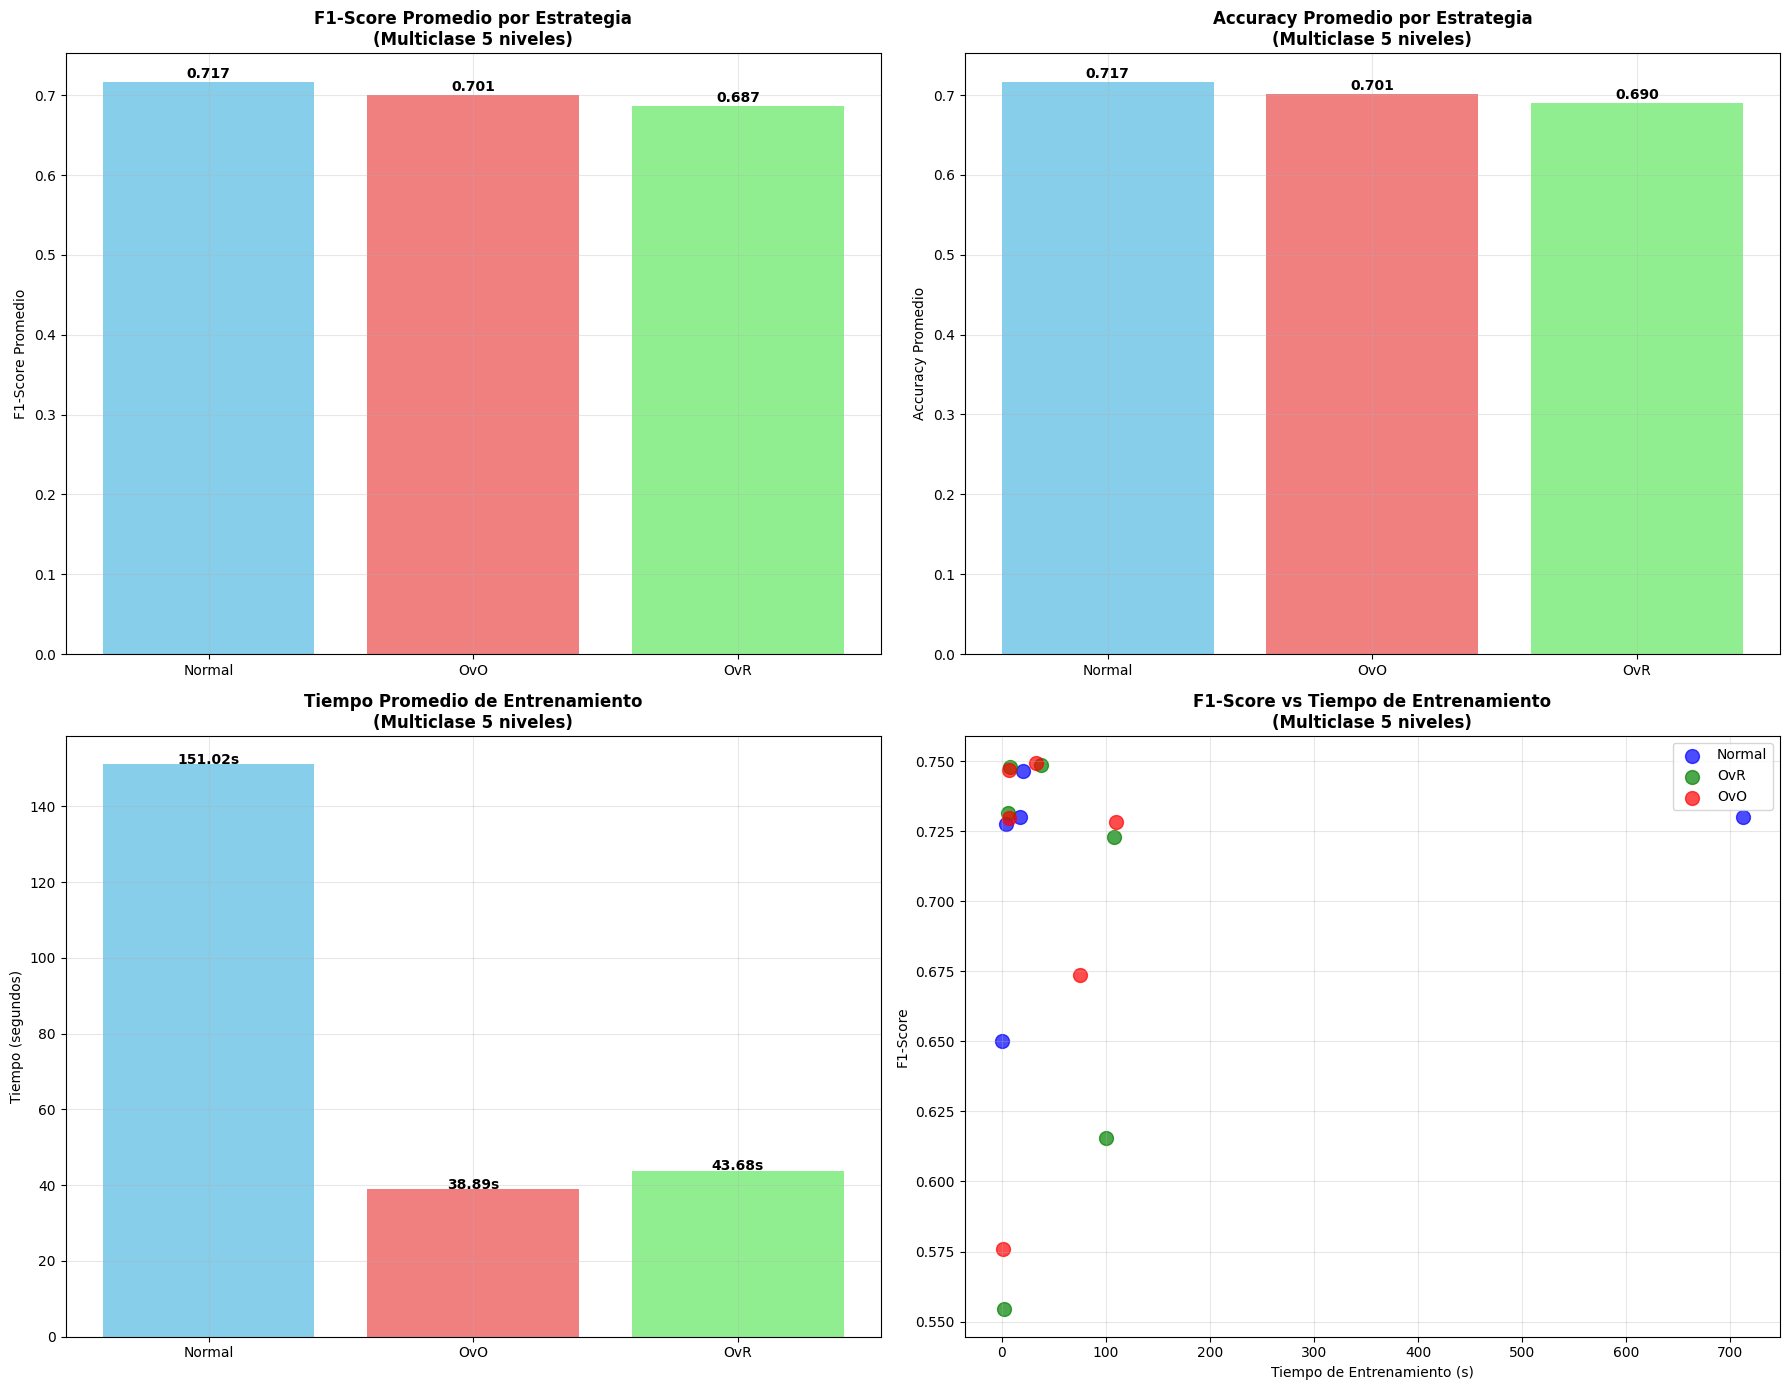

           F1-Score                 Accuracy                  \
               mean     std     max     mean     std     max   
Estrategia                                                     
Normal       0.7168  0.0380  0.7464   0.7167  0.0379  0.7468   
OvO          0.7006  0.0669  0.7493   0.7008  0.0658  0.7493   
OvR          0.6868  0.0818  0.7485   0.6903  0.0763  0.7486   

           Tiempo Entrenamiento            
                           mean       std  
Estrategia                                 
Normal                 151.0165  313.8158  
OvO                     38.8941   44.5210  
OvR                     43.6833   48.3162  
Normal:
   Modelo: Random Forest
   F1-Score: 0.7464
   Accuracy: 0.7468
   Tiempo: 20.35s

OvR:
   Modelo: Random Forest
   F1-Score: 0.7485
   Accuracy: 0.7486
   Tiempo: 38.17s

OvO:
   Modelo: Random Forest
   F1-Score: 0.7493
   Accuracy: 0.7493
   Tiempo: 33.07s


Comparación completada para clasificación multiclase (5 niveles)


In [ ]:

all_multi5_results = []

for result in multiclass5_results: 
    all_multi5_results.append({
        'Modelo': result['model_name'],
        'Estrategia': 'Normal',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })


for result in ovr_multi5_results:
    all_multi5_results.append({
        'Modelo': result['model_name'].replace('OvR ', ''),
        'Estrategia': 'OvR',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })
for result in ovo_multi5_results:
    all_multi5_results.append({
        'Modelo': result['model_name'].replace('OvR ', ''),
        'Estrategia': 'OvO',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })
comparison_multi5_df = pd.DataFrame(all_multi5_results)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

strategy_f1_5 = comparison_multi5_df.groupby('Estrategia')['F1-Score'].mean()
axes[0,0].bar(strategy_f1_5.index, strategy_f1_5.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0,0].set_title('F1-Score Promedio por Estrategia\n(Multiclase 5 niveles)', fontweight='bold')
axes[0,0].set_ylabel('F1-Score Promedio')
axes[0,0].grid(True, alpha=0.3)
for i, v in enumerate(strategy_f1_5.values):
    axes[0,0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

strategy_acc_5 = comparison_multi5_df.groupby('Estrategia')['Accuracy'].mean()
axes[0,1].bar(strategy_acc_5.index, strategy_acc_5.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0,1].set_title('Accuracy Promedio por Estrategia\n(Multiclase 5 niveles)', fontweight='bold')
axes[0,1].set_ylabel('Accuracy Promedio')
axes[0,1].grid(True, alpha=0.3)
for i, v in enumerate(strategy_acc_5.values):
    axes[0,1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

strategy_time_5 = comparison_multi5_df.groupby('Estrategia')['Tiempo Entrenamiento'].mean()
axes[1,0].bar(strategy_time_5.index, strategy_time_5.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1,0].set_title('Tiempo Promedio de Entrenamiento\n(Multiclase 5 niveles)', fontweight='bold')
axes[1,0].set_ylabel('Tiempo (segundos)')
axes[1,0].grid(True, alpha=0.3)
for i, v in enumerate(strategy_time_5.values):
    axes[1,0].text(i, v + 0.2, f'{v:.2f}s', ha='center', fontweight='bold')


colors_map = {'Normal': 'blue', 'OvO': 'red', 'OvR': 'green'}
for strategy in comparison_multi5_df['Estrategia'].unique():
    data = comparison_multi5_df[comparison_multi5_df['Estrategia'] == strategy]
    axes[1,1].scatter(data['Tiempo Entrenamiento'], data['F1-Score'], 
                     label=strategy, color=colors_map[strategy], s=100, alpha=0.7)

axes[1,1].set_title('F1-Score vs Tiempo de Entrenamiento\n(Multiclase 5 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo de Entrenamiento (s)')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

summary_5_levels = comparison_multi5_df.groupby('Estrategia').agg({
    'F1-Score': ['mean', 'std', 'max'],
    'Accuracy': ['mean', 'std', 'max'],
    'Tiempo Entrenamiento': ['mean', 'std']
}).round(4)

print(summary_5_levels)

for strategy in comparison_multi5_df['Estrategia'].unique():
    best_model = comparison_multi5_df[comparison_multi5_df['Estrategia'] == strategy].loc[
        comparison_multi5_df[comparison_multi5_df['Estrategia'] == strategy]['F1-Score'].idxmax()
    ]
    print(f"{strategy}:")
    print(f"   Modelo: {best_model['Modelo']}")
    print(f"   F1-Score: {best_model['F1-Score']:.4f}")
    print(f"   Accuracy: {best_model['Accuracy']:.4f}")
    print(f"   Tiempo: {best_model['Tiempo Entrenamiento']:.2f}s")
    print()

print(f"\nComparación completada para clasificación multiclase (5 niveles)")

In [ ]:
xg = xgboost.XGBClassifier(objective='binary:logistic')
xg.fit(X_train_bin,y_train_bin)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
xg

In [ ]:
xg_3 = xgboost.XGBClassifier(objective='multi:softmax',eval_metrics = 'mlogloss',num_class=3)
xg_3.fit(X_train_multi3,y_train_multi3)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
xg_5 = xgboost.XGBClassifier(objective='multi:softmax',eval_metrics = 'mlogloss',num_class=5)
xg_5.fit(X_train_multi5,y_train_multi5)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
